# 📊 QQQ Weekly Research — Estructura, Regímenes y Señales
## Pipeline: Features → UMAP/HDBSCAN → XGBoost Forecast → Señales → Score → Backtest

---

**Objetivo:** Investigar si la estructura interna del mercado semanal de QQQ
(capturada mediante clustering no supervisado) genera señales predecibles y
útiles para construir estrategias con ventaja estadística.

**Contexto:** La premisa original era usar regímenes de mercado como hedge via ML.
Ese enfoque no generó alpha directo, pero el proceso investigativo reveló
patrones valiosos sobre la estructura del mercado, la efectividad condicional de
señales técnicas y la utilidad del forecast como filtro de posición.

Este notebook documenta ese recorrido de manera ordenada, con énfasis educativo.

---

### 🗺️ Mapa del Notebook

| # | Parte | Descripción |
|---|-------|-------------|
| 0 | **Setup** | Librerías, funciones base y parámetros |
| 1 | **Datos y Features** | Descarga QQQ, construcción de indicadores técnicos |
| 2 | **Estructura No Supervisada** | UMAP + HDBSCAN: clusters y meta-estados |
| 3 | **Forecast Supervisado** | XGBoost: predecir régimen futuro |
| 4 | **Calibración del Forecast** | ¿Qué tan confiables son las probabilidades? |
| 5 | **Anatomía de los Regímenes** | Estadísticas, duración y transiciones |
| 6 | **Señales Técnicas** | RSI, BB, SMA, MOM — eficacia por régimen |
| 7 | **¿Agrega Valor el Forecast?** | Análisis condicional y de contribución |
| 8 | **Motor de Score** | Score ponderado, signatures y robustez |
| 9 | **Backtesting** | Estrategias V0→V4 y backtest de signature |
| 10 | **Conclusiones** | Hallazgos clave |

---


---
## ⚙️ Parte 0 — Setup
### BLOQUE 0 — Instalación de dependencias

Librerías necesarias que no vienen por defecto en entornos estándar.


In [1]:
# =========================================================
# BLOQUE 0 — INSTALACIÓN
# =========================================================
# Ejecutar solo si las librerías no están instaladas.

# !pip install yfinance umap-learn hdbscan scikit-learn xgboost pandas numpy matplotlib seaborn


### BLOQUE 1 — Librerías, parámetros y configuración global

Centralizamos aquí **todos** los imports y los parámetros que controlan el
pipeline completo. Si querés cambiar el ticker, las fechas o los hiperparámetros
del modelo, este es el único lugar donde hacerlo.


In [2]:
# =========================================================
# BLOQUE 1 — LIBRERÍAS Y PARÁMETROS GLOBALES
# =========================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import yfinance as yf
from scipy.stats import skew, kurtosis
from itertools import combinations

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_auc_score
)

import umap
import hdbscan
from xgboost import XGBClassifier

plt.style.use("default")
plt.rcParams["figure.figsize"] = (14, 5)

# ─── Parámetros del pipeline ──────────────────────────────
TICKER      = "QQQ"
START_DATE  = "2000-01-01"

# Clustering
UMAP_NEIGHBORS      = 20
UMAP_MIN_DIST       = 0.05
HDBSCAN_MIN_CLUSTER = 12
HDBSCAN_MIN_SAMPLES = 6

# Forecast
FUTURE_HORIZON = 4        # semanas a futuro para el target
TEST_SIZE      = 0.30     # fracción del conjunto de prueba

print("✅ Librerías cargadas correctamente.")


✅ Librerías cargadas correctamente.


### BLOQUE 2 — Funciones base del pipeline

Definimos todas las funciones auxiliares en un único bloque para mantener los
bloques de análisis limpios y centrados en la lógica de investigación.

- `add_weekly_features`: construye el universo de features técnicos.
- `forward_return / forward_drawdown`: calculan targets hacia el futuro.
- `structure_clustering`: aplica UMAP + HDBSCAN.
- `forward_metrics_summary`: agrega métricas por cluster.
- `cluster_score / assign_cluster_labels`: asigna meta-estados (bull/neutral/stress).
- `transition_matrix / cluster_persistence`: analiza dinámicas de régimen.


In [3]:
# =========================================================
# BLOQUE 2 — FUNCIONES BASE
# =========================================================

# ─── Normalización de columnas yfinance ──────────────────
def flatten_yf_columns(df: pd.DataFrame) -> pd.DataFrame:
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = [c[0] if isinstance(c, tuple) else c for c in df.columns]
    return df


# ─── Construcción de features técnicos semanales ─────────
def add_weekly_features(df: pd.DataFrame) -> pd.DataFrame:
    df    = df.copy()
    price = df["Close"].copy()

    # Retornos
    df["returns"]     = price.pct_change()
    df["log_returns"] = np.log(price / price.shift(1))

    # Volatilidad rolling
    df["vol_4"]  = df["returns"].rolling(4).std()
    df["vol_13"] = df["returns"].rolling(13).std()
    df["vol_26"] = df["returns"].rolling(26).std()

    # Momentum
    df["mom_4"]  = price / price.shift(4)  - 1
    df["mom_13"] = price / price.shift(13) - 1
    df["mom_26"] = price / price.shift(26) - 1
    df["mom_52"] = price / price.shift(52) - 1

    # Tendencia (SMAs)
    df["sma_4"]  = price.rolling(4).mean()
    df["sma_13"] = price.rolling(13).mean()
    df["sma_26"] = price.rolling(26).mean()
    df["sma_52"] = price.rolling(52).mean()

    df["trend_13_52"]      = df["sma_13"] / df["sma_52"] - 1
    df["price_vs_sma_52"]  = price / df["sma_52"] - 1
    df["sma13_slope"]      = df["sma_13"].pct_change(3)

    # Breakouts
    df["high_13"]         = df["High"].rolling(13).max()
    df["low_13"]          = df["Low"].rolling(13).min()
    df["breakout_13"]     = price / df["high_13"] - 1
    df["breakdown_13"]    = price / df["low_13"]  - 1
    df["high_26"]         = df["High"].rolling(26).max()
    df["breakout_26"]     = price / df["high_26"] - 1

    range_13 = (df["high_13"] - df["low_13"]).replace(0, np.nan)
    df["range_position_13"] = (price - df["low_13"]) / range_13

    # ATR (Average True Range)
    tr1 = df["High"] - df["Low"]
    tr2 = (df["High"] - df["Close"].shift(1)).abs()
    tr3 = (df["Low"]  - df["Close"].shift(1)).abs()
    df["tr"]      = np.maximum.reduce([tr1.values, tr2.values, tr3.values])
    df["atr_4"]   = df["tr"].rolling(4).mean()
    df["atr_13"]  = df["tr"].rolling(13).mean()
    df["atr_pct"] = df["atr_13"] / price

    # Drawdown desde máximo histórico
    df["cummax"]   = price.cummax()
    df["drawdown"] = price / df["cummax"] - 1

    # Volumen relativo
    df["vol_rel_4"] = df["Volume"] / df["Volume"].rolling(4).mean()

    return df.dropna().copy()


# ─── Targets forward ─────────────────────────────────────
def forward_return(close: pd.Series, horizon: int) -> pd.Series:
    return close.shift(-horizon) / close - 1


def forward_drawdown(close: pd.Series, horizon: int) -> pd.Series:
    s   = close.values
    out = np.full(len(s), np.nan, dtype=float)
    for i in range(len(s) - horizon):
        future_window = s[i + 1 : i + horizon + 1]
        if len(future_window) == 0:
            continue
        out[i] = np.min(future_window) / s[i] - 1
    return pd.Series(out, index=close.index)


# ─── Clustering UMAP + HDBSCAN ───────────────────────────
def structure_clustering(
    df, feature_cols,
    n_neighbors=20, min_dist=0.05,
    min_cluster_size=12, min_samples=6,
    random_state=42
):
    work = df.copy()
    X    = work[feature_cols].copy()

    scaler = StandardScaler()
    Xs     = scaler.fit_transform(X)

    reducer = umap.UMAP(
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        n_components=2,
        random_state=random_state
    )
    emb = reducer.fit_transform(Xs)

    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=min_cluster_size,
        min_samples=min_samples,
        cluster_selection_method="eom",
        prediction_data=True
    )
    labels = clusterer.fit_predict(emb)

    work["umap_1"]       = emb[:, 0]
    work["umap_2"]       = emb[:, 1]
    work["cluster"]      = labels
    work["cluster_prob"] = clusterer.probabilities_

    return work, reducer, clusterer


# ─── Métricas futuras por cluster ────────────────────────
def forward_metrics_summary(df, cluster_col="cluster", horizons=(1, 4, 12)):
    work  = df.copy()
    close = work["Close"]

    for h in horizons:
        work[f"fwd_ret_{h}"] = forward_return(close, h)
        work[f"fwd_dd_{h}"]  = forward_drawdown(close, h)

    agg_dict = {
        "count":               ("returns",       "size"),
        "mean_return":         ("returns",       "mean"),
        "vol":                 ("returns",       "std"),
        "mean_drawdown":       ("drawdown",      "mean"),
        "mean_cluster_prob":   ("cluster_prob",  "mean"),
        "mean_mom_4":          ("mom_4",         "mean"),
        "mean_mom_13":         ("mom_13",        "mean"),
        "mean_mom_52":         ("mom_52",        "mean"),
        "mean_trend_13_52":    ("trend_13_52",   "mean"),
        "mean_price_vs_sma_52":("price_vs_sma_52","mean"),
        "mean_breakout_26":    ("breakout_26",   "mean"),
    }
    for h in horizons:
        agg_dict[f"fwd_ret_{h}"] = (f"fwd_ret_{h}", "mean")
        agg_dict[f"fwd_dd_{h}"]  = (f"fwd_dd_{h}",  "mean")

    summary = (
        work.groupby(cluster_col)
        .agg(**agg_dict)
        .sort_values("mean_return", ascending=False)
    )
    return summary, work


# ─── Score económico y etiquetas de cluster ──────────────
def cluster_score(summary, ret_col, dd_col, vol_col="vol"):
    x     = summary[[ret_col, dd_col, vol_col]].copy()
    x     = (x - x.mean()) / x.std(ddof=0)
    score = x[ret_col] - x[dd_col] - 0.5 * x[vol_col]
    return score


def assign_cluster_labels(summary):
    labels  = pd.Series(index=summary.index, dtype="object")
    if -1 in summary.index:
        labels.loc[-1] = "anomaly"

    usable = [c for c in summary.index if c != -1]
    if not usable:
        return labels

    score  = cluster_score(
        summary.loc[usable],
        ret_col="fwd_ret_12", dd_col="fwd_dd_12", vol_col="vol"
    )
    ranked = score.sort_values(ascending=False)
    n      = len(ranked)
    top_n  = max(1, n // 3)
    bot_n  = max(1, n // 3)

    bull    = ranked.index[:top_n].tolist()
    stress  = ranked.index[-bot_n:].tolist()
    neutral = [c for c in ranked.index if c not in bull and c not in stress]

    labels.loc[bull]    = "bull"
    labels.loc[neutral] = "neutral"
    labels.loc[stress]  = "stress"
    return labels


# ─── Persistencia y matriz de transición ─────────────────
def cluster_persistence(df, cluster_col="cluster"):
    x    = df[cluster_col].copy()
    runs = []
    current_cluster = None
    start = prev_idx = None

    for idx, val in x.items():
        if pd.isna(val):
            continue
        val = int(val)
        if current_cluster is None:
            current_cluster, start, prev_idx = val, idx, idx
            continue
        if val != current_cluster:
            duration = df.loc[start:prev_idx].shape[0]
            runs.append((current_cluster, duration))
            current_cluster, start = val, idx
        prev_idx = idx

    if current_cluster is not None:
        runs.append((current_cluster, df.loc[start:prev_idx].shape[0]))

    if not runs:
        return pd.DataFrame(columns=["cluster", "mean_duration",
                                     "median_duration", "max_duration", "count_runs"])

    run_df  = pd.DataFrame(runs, columns=["cluster", "duration"])
    summary = (
        run_df.groupby("cluster")["duration"]
        .agg(["mean", "median", "max", "count"])
        .rename(columns={"mean": "mean_duration", "median": "median_duration",
                         "max": "max_duration",   "count": "count_runs"})
        .sort_index()
    )
    return summary


def transition_matrix(df, cluster_col="cluster"):
    return pd.crosstab(
        df[cluster_col].shift(1),
        df[cluster_col],
        normalize="index"
    )


# ─── Métricas de backtest ─────────────────────────────────
def cagr(equity_series, periods_per_year=52):
    years = len(equity_series) / periods_per_year
    return equity_series.iloc[-1] ** (1 / years) - 1

def max_dd(equity_series):
    return (equity_series / equity_series.cummax() - 1).min()

def sharpe(return_series, periods_per_year=52):
    if return_series.std() == 0:
        return np.nan
    return (return_series.mean() / return_series.std()) * np.sqrt(periods_per_year)


print("✅ Funciones base definidas correctamente.")


✅ Funciones base definidas correctamente.


---
## 📥 Parte 1 — Datos y Features
### BLOQUE 3 — Descarga y preparación de datos

Descargamos QQQ desde Yahoo Finance con datos diarios y lo re-sampleamos a
frecuencia semanal (cierre de viernes). Trabajamos semanalmente porque:

- Reduce el ruido intra-semanal sin perder tendencias importantes.
- Es consistente con la mayoría de señales de momentum (4, 13, 26, 52 semanas).
- El horizonte de inversión típico para estrategias basadas en régimen es de
  semanas, no días.


In [4]:
# =========================================================
# BLOQUE 3 — DESCARGA Y PREPARACIÓN DE DATOS
# =========================================================

# ─── Datos diarios ───────────────────────────────────────
daily_raw = yf.download(
    TICKER, start=START_DATE,
    auto_adjust=True, progress=False
)
daily_raw = flatten_yf_columns(daily_raw).dropna().copy()

print(f"Datos diarios: {daily_raw.index[0].date()} → {daily_raw.index[-1].date()}")
print(f"Filas: {len(daily_raw):,}  |  Columnas: {list(daily_raw.columns)}")

# ─── Re-sampleo semanal (cierre de viernes) ──────────────
weekly_raw = daily_raw.resample("W-FRI").agg({
    "Open":   "first",
    "High":   "max",
    "Low":    "min",
    "Close":  "last",
    "Volume": "sum",
}).dropna().copy()

print(f"\nDatos semanales: {weekly_raw.index[0].date()} → {weekly_raw.index[-1].date()}")
print(f"Semanas totales: {len(weekly_raw):,}")


Datos diarios: 2000-01-03 → 2026-06-01
Filas: 6,642  |  Columnas: ['Close', 'High', 'Low', 'Open', 'Volume']

Datos semanales: 2000-01-07 → 2026-06-05
Semanas totales: 1,379


### BLOQUE 4 — Ingeniería de features técnicos

Construimos el universo de features que describe el estado del mercado en cada
semana. Los features se organizan en 7 categorías:

| Categoría | Features | Intuición |
|-----------|----------|-----------|
| **Retorno** | returns, log_returns | Movimiento reciente |
| **Volatilidad** | vol_4/13/26 | Nivel de riesgo activo |
| **Momentum** | mom_4/13/26/52 | Fuerza de la tendencia |
| **Tendencia** | trend_13_52, price_vs_sma_52, sma13_slope | Posición relativa al largo plazo |
| **Breakouts** | breakout_13/26, breakdown_13, range_position_13 | Niveles clave |
| **Riesgo** | atr_pct, drawdown | Caídas y amplitud de movimiento |
| **Volumen** | vol_rel_4 | Confirmación de movimiento |

**Nota:** Todos los features usan solo datos disponibles al momento del cálculo —
sin lookahead bias.


In [5]:
# =========================================================
# BLOQUE 4 — INGENIERÍA DE FEATURES
# =========================================================

weekly = add_weekly_features(weekly_raw)

# Lista de features usados para clustering
FEATURE_COLS = [
    "returns",
    "vol_4", "vol_13", "vol_26",
    "mom_4", "mom_13", "mom_26", "mom_52",
    "trend_13_52", "sma13_slope", "price_vs_sma_52",
    "breakout_13", "breakout_26", "breakdown_13",
    "range_position_13",
    "atr_pct",
    "drawdown",
    "vol_rel_4",
]

print(f"Semanas tras dropna: {len(weekly):,}")
print(f"Features construidos: {len(FEATURE_COLS)}")
print(f"\nPrimeras 3 filas:")
display(weekly[FEATURE_COLS].head(3).round(4))


Semanas tras dropna: 1,327
Features construidos: 18

Primeras 3 filas:


,returns,vol_4,vol_13,vol_26,mom_4,mom_13,mom_26,mom_52,trend_13_52,sma13_slope,price_vs_sma_52,breakout_13,breakout_26,breakdown_13,range_position_13,atr_pct,drawdown,vol_rel_4
Date,,,,,,,,,,,,,,,,,,
2001-01-05,-0.0300,0.0145,0.0598,0.0560,-0.1673,-0.3178,-0.4098,-0.3708,-0.2089,-0.0887,-0.3647,-0.3556,-0.4530,0.0857,0.1251,0.1889,-0.5183,1.1818
2001-01-12,0.1079,0.0743,0.0707,0.0599,-0.0179,-0.2279,-0.3766,-0.3281,-0.2197,-0.0773,-0.2915,-0.2861,-0.3940,0.2028,0.2962,0.1726,-0.4664,1.1084
2001-01-19,0.0570,0.0696,0.0702,0.0615,0.0961,-0.2317,-0.3164,-0.3110,-0.2321,-0.0688,-0.2462,-0.2421,-0.3594,0.2714,0.4005,0.1568,-0.4359,0.8417


#### BLOQUE 4B — Exploración rápida: correlación de features con retorno futuro

Antes de entrenar cualquier modelo, hacemos un análisis univariado simple:
¿cuánto se correlaciona cada feature con el retorno de las próximas 12 semanas?

Esto nos da una primera lectura de qué variables tienen señal predictiva bruta.
Valores absolutos altos (>0.10) ya son interesantes en datos financieros.


Top features por correlación absoluta con retorno 12W:


,feature,corr_fwd_12,abs_corr
8,trend_13_52,0.1186,0.1186
15,atr_pct,-0.1016,0.1016
16,drawdown,0.0897,0.0897
10,price_vs_sma_52,0.0851,0.0851
6,mom_26,0.0849,0.0849
12,breakout_26,0.0757,0.0757
7,mom_52,0.0744,0.0744
13,breakdown_13,-0.0722,0.0722
2,vol_13,-0.0680,0.0680
3,vol_26,-0.0624,0.0624


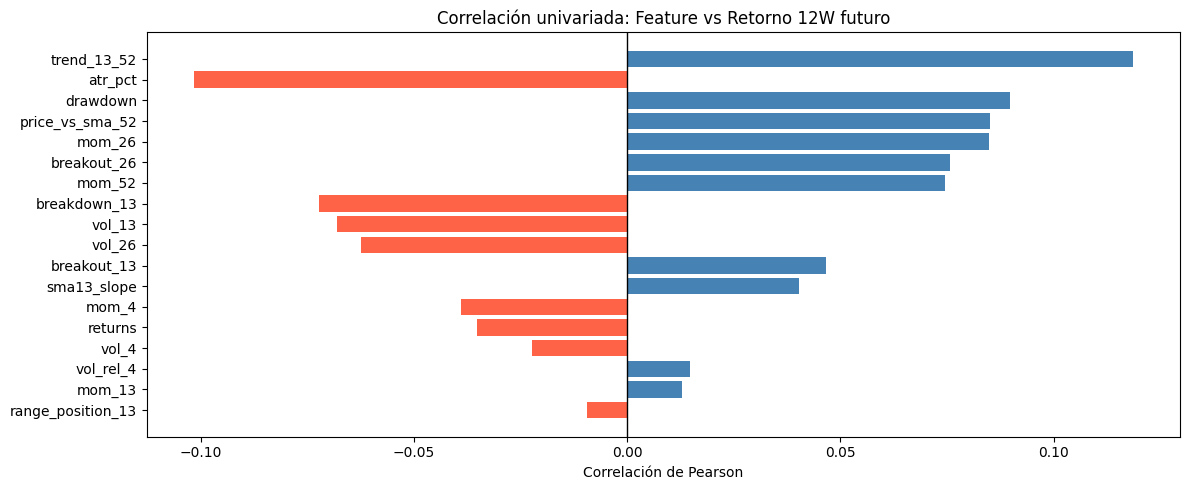

In [6]:
# =========================================================
# BLOQUE 4B — CORRELACIÓN CON RETORNO FUTURO (12 semanas)
# =========================================================

tmp = weekly.copy()
tmp["fwd_ret_12"] = forward_return(tmp["Close"], 12)

corr_table = []
for feat in FEATURE_COLS:
    subset = tmp[[feat, "fwd_ret_12"]].dropna()
    c = subset[feat].corr(subset["fwd_ret_12"])
    corr_table.append({"feature": feat, "corr_fwd_12": round(c, 4), "abs_corr": round(abs(c), 4)})

corr_df = pd.DataFrame(corr_table).sort_values("abs_corr", ascending=False)

print("Top features por correlación absoluta con retorno 12W:")
display(corr_df.head(10))

# Gráfico
plt.figure(figsize=(12, 5))
plt.barh(
    corr_df["feature"].values[::-1],
    corr_df["corr_fwd_12"].values[::-1],
    color=["steelblue" if v > 0 else "tomato" for v in corr_df["corr_fwd_12"].values[::-1]]
)
plt.axvline(0, color="black", linewidth=1)
plt.title("Correlación univariada: Feature vs Retorno 12W futuro")
plt.xlabel("Correlación de Pearson")
plt.tight_layout()
plt.show()


---
## 🔍 Parte 2 — Estructura No Supervisada: UMAP + HDBSCAN
### BLOQUE 5 — Clustering del mercado

**¿Por qué clustering no supervisado?**

En lugar de imponer a priori qué es un mercado "alcista" o "bajista",
dejamos que los datos se organicen solos. La intuición es:

1. **UMAP** reduce los 18 features a 2 dimensiones preservando la estructura
   de vecindad (semanas similares quedan cerca).
2. **HDBSCAN** identifica grupos densos en ese espacio 2D sin requerir que
   definamos el número de clusters de antemano.

El resultado son clusters que representan **estados de mercado empíricos** —
no nuestras hipótesis, sino lo que los datos muestran.

El cluster `-1` son puntos que HDBSCAN no asignó a ningún grupo (anomalías o
puntos de transición). Es información en sí misma.


In [7]:
# =========================================================
# BLOQUE 5 — CLUSTERING UMAP + HDBSCAN
# =========================================================

weekly_clust, umap_model, hdb_model = structure_clustering(
    weekly,
    feature_cols=FEATURE_COLS,
    n_neighbors=UMAP_NEIGHBORS,
    min_dist=UMAP_MIN_DIST,
    min_cluster_size=HDBSCAN_MIN_CLUSTER,
    min_samples=HDBSCAN_MIN_SAMPLES,
    random_state=42
)

cluster_counts = weekly_clust["cluster"].value_counts().sort_index()
print("Clusters encontrados:")
for c, n in cluster_counts.items():
    label = "anomaly" if c == -1 else f"cluster {c}"
    print(f"  {label:15s}: {n:4d} semanas  ({n/len(weekly_clust)*100:.1f}%)")


Clusters encontrados:
  anomaly        :  201 semanas  (15.1%)
  cluster 0      :  518 semanas  (39.0%)
  cluster 1      :  113 semanas  (8.5%)
  cluster 2      :   30 semanas  (2.3%)
  cluster 3      :   15 semanas  (1.1%)
  cluster 4      :   23 semanas  (1.7%)
  cluster 5      :   35 semanas  (2.6%)
  cluster 6      :   59 semanas  (4.4%)
  cluster 7      :   18 semanas  (1.4%)
  cluster 8      :   28 semanas  (2.1%)
  cluster 9      :   25 semanas  (1.9%)
  cluster 10     :   19 semanas  (1.4%)
  cluster 11     :   14 semanas  (1.1%)
  cluster 12     :   50 semanas  (3.8%)
  cluster 13     :   30 semanas  (2.3%)
  cluster 14     :   18 semanas  (1.4%)
  cluster 15     :   17 semanas  (1.3%)
  cluster 16     :   20 semanas  (1.5%)
  cluster 17     :   18 semanas  (1.4%)
  cluster 18     :   24 semanas  (1.8%)
  cluster 19     :   33 semanas  (2.5%)
  cluster 20     :   19 semanas  (1.4%)


### BLOQUE 6 — Visualización de clusters

Dos perspectivas del clustering:

- **Izquierda:** El espacio UMAP (estructura latente) — semanas cercanas tienen
  features similares.
- **Derecha:** El precio coloreado por cluster — nos dice cuándo ocurrió cada
  estado de mercado.


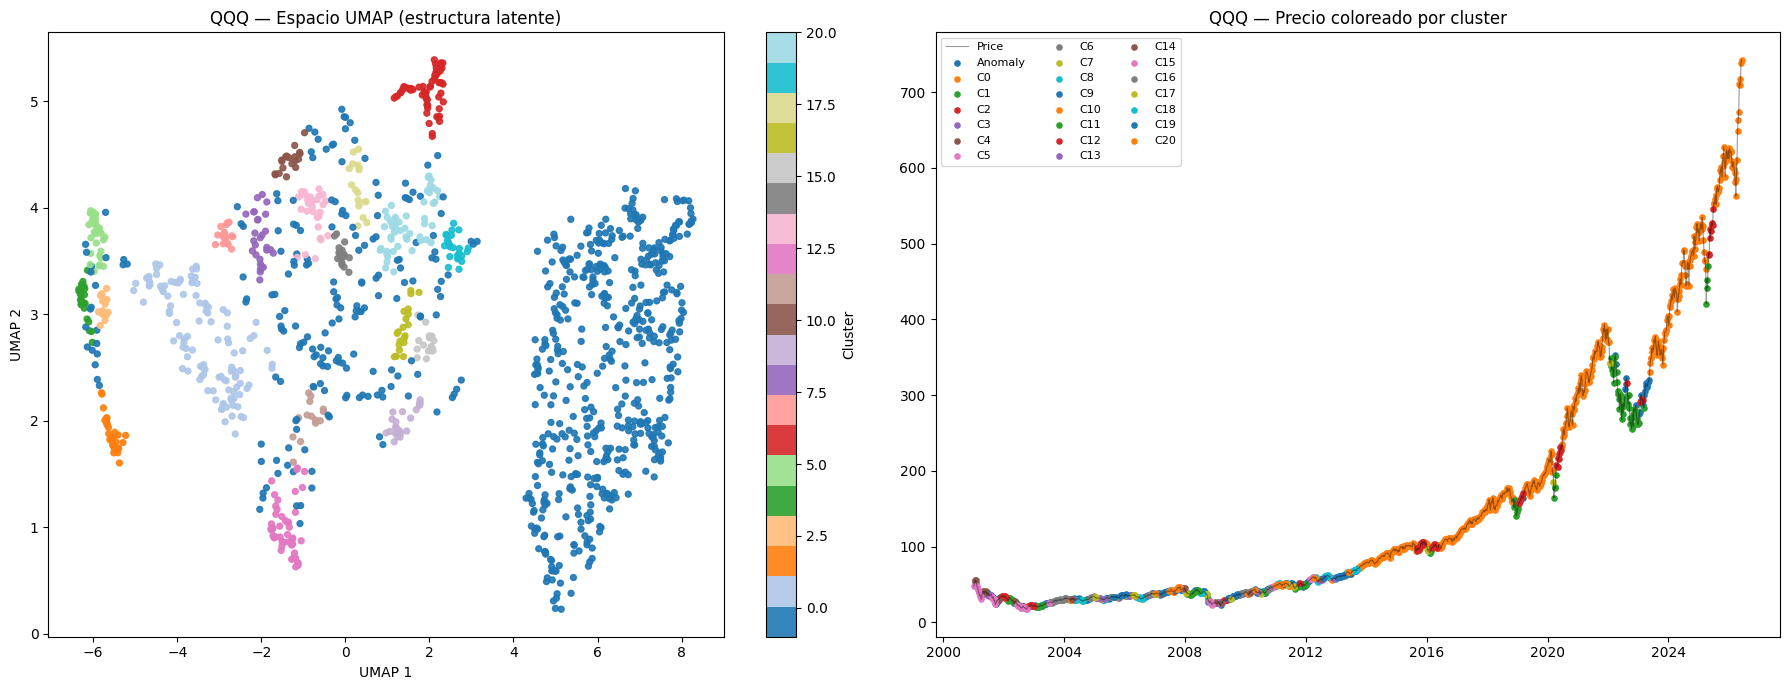

In [8]:
# =========================================================
# BLOQUE 6 — VISUALIZACIÓN UMAP Y PRECIO POR CLUSTER
# =========================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# ─── Panel izquierdo: espacio UMAP ───────────────────────
sc = axes[0].scatter(
    weekly_clust["umap_1"], weekly_clust["umap_2"],
    c=weekly_clust["cluster"], s=18, cmap="tab20", alpha=0.9
)
axes[0].set_title("QQQ — Espacio UMAP (estructura latente)")
axes[0].set_xlabel("UMAP 1")
axes[0].set_ylabel("UMAP 2")
plt.colorbar(sc, ax=axes[0], label="Cluster")

# ─── Panel derecho: precio coloreado por cluster ─────────
axes[1].plot(
    weekly_clust.index, weekly_clust["Close"],
    color="black", linewidth=0.8, alpha=0.4, label="Price"
)
for c in sorted(weekly_clust["cluster"].dropna().unique()):
    mask = weekly_clust["cluster"] == c
    axes[1].scatter(
        weekly_clust.index[mask], weekly_clust["Close"][mask],
        s=14, label=f"C{int(c)}" if c != -1 else "Anomaly"
    )
axes[1].set_title("QQQ — Precio coloreado por cluster")
axes[1].legend(fontsize=8, ncol=3)

plt.tight_layout()
plt.show()


### BLOQUE 7 — Persistencia y matriz de transición

- **Persistencia:** ¿Cuántas semanas dura típicamente cada cluster?
  Clusters muy cortos son más ruidosos; clusters largos sugieren estados estables.
- **Matriz de transición:** ¿Cómo se pasa de un cluster a otro?
  Diagonal alta = estado estable. Valores fuera de diagonal = transiciones frecuentes.


In [9]:
# =========================================================
# BLOQUE 7 — PERSISTENCIA Y TRANSICIONES DE CLUSTERS
# =========================================================

pers  = cluster_persistence(weekly_clust, cluster_col="cluster")
trans = transition_matrix(weekly_clust, cluster_col="cluster")

print("\n📊 PERSISTENCIA POR CLUSTER (semanas)")
print("─" * 50)
display(pers.round(2))

print("\n📊 MATRIZ DE TRANSICIÓN (probabilidades)")
print("─" * 50)
display(trans.round(3))



📊 PERSISTENCIA POR CLUSTER (semanas)
──────────────────────────────────────────────────


,mean_duration,median_duration,max_duration,count_runs
cluster,,,,
-1,2.09,1.0,9,96
0,64.75,67.0,133,8
1,5.95,4.0,15,19
2,10.00,10.0,11,3
3,3.00,3.0,5,5
4,1.92,1.0,7,12
5,3.89,3.0,9,9
6,19.67,16.0,35,3
7,1.80,2.0,3,10



📊 MATRIZ DE TRANSICIÓN (probabilidades)
──────────────────────────────────────────────────


cluster,-1,0,1,2,3,4,5,6,7,8,...,11,12,13,14,15,16,17,18,19,20
cluster,,,,,,,,,,,,,,,,,,,,,
-1.0,0.522,0.010,0.030,0.010,0.015,0.030,0.025,0.010,0.015,0.030,...,0.025,0.035,0.015,0.025,0.010,0.035,0.025,0.025,0.035,0.025
0.0,0.000,0.986,0.004,0.000,0.000,0.000,0.000,0.000,0.008,0.000,...,0.000,0.002,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
1.0,0.115,0.000,0.832,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.018,0.035,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
2.0,0.033,0.000,0.033,0.900,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
3.0,0.200,0.000,0.000,0.067,0.667,0.000,0.067,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
4.0,0.304,0.000,0.043,0.000,0.087,0.478,0.087,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
5.0,0.086,0.000,0.000,0.000,0.000,0.171,0.743,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
6.0,0.051,0.000,0.000,0.000,0.000,0.000,0.000,0.949,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
7.0,0.056,0.056,0.389,0.000,0.000,0.000,0.000,0.000,0.444,0.056,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000


### BLOQUE 8 — Métricas futuras por cluster y retornos forward

Ahora vinculamos cada cluster con lo que ocurre **después**: retornos y
drawdowns futuros a 1, 4 y 12 semanas.

También calculamos aquí **todos los targets forward** que usaremos a lo largo
del notebook (1W, 4W, 12W, 24W) para evitar recalcularlos en cada bloque.


📊 RESUMEN POR CLUSTER (retornos y drawdowns futuros)


,count,mean_return,vol,mean_drawdown,mean_cluster_prob,mean_mom_4,mean_mom_13,mean_mom_52,mean_trend_13_52,mean_price_vs_sma_52,mean_breakout_26,fwd_ret_1,fwd_dd_1,fwd_ret_4,fwd_dd_4,fwd_ret_12,fwd_dd_12
cluster,,,,,,,,,,,,,,,,,
4,23,0.0551,0.0656,-0.6485,0.8790,0.0470,-0.2108,-0.4136,-0.2716,-0.3015,-0.3813,0.0026,0.0026,-0.0273,-0.0603,-0.0717,-0.1528
14,18,0.0150,0.0190,-0.5620,0.8832,0.0136,0.0269,0.2248,0.0880,0.0959,-0.0411,-0.0042,-0.0042,-0.0005,-0.0289,-0.0111,-0.0529
9,25,0.0146,0.0244,-0.6304,0.8159,0.0646,0.1828,-0.0999,0.0593,0.1420,-0.0158,0.0062,0.0062,0.0292,-0.0054,0.1025,-0.0061
12,50,0.0129,0.0251,-0.0767,0.7348,0.0627,0.0182,0.0926,-0.0080,0.0400,-0.0614,0.0074,0.0074,0.0327,-0.0050,0.0774,-0.0195
18,24,0.0113,0.0141,-0.3665,0.9013,0.0369,0.0923,0.2382,0.0741,0.1235,-0.0075,-0.0013,-0.0013,-0.0124,-0.0223,0.0164,-0.0506
2,30,0.0091,0.0329,-0.7199,0.8782,0.0574,0.1612,-0.3288,-0.1719,-0.1058,-0.1158,0.0083,0.0083,0.0036,-0.0259,0.0025,-0.0715
16,20,0.0079,0.0133,-0.6400,0.9459,0.0499,0.1428,0.1201,0.0144,0.0794,-0.0119,0.0045,0.0045,0.0100,-0.0084,0.0005,-0.0279
19,33,0.0076,0.0114,-0.5110,0.8733,0.0274,0.0534,0.1078,0.0401,0.0751,-0.0186,-0.0001,-0.0001,0.0111,-0.0077,0.0342,-0.0143
15,17,0.0075,0.0129,-0.5020,0.9264,0.0386,0.1717,0.2033,0.0704,0.1473,-0.0123,0.0030,0.0030,0.0158,-0.0044,0.0073,-0.0465


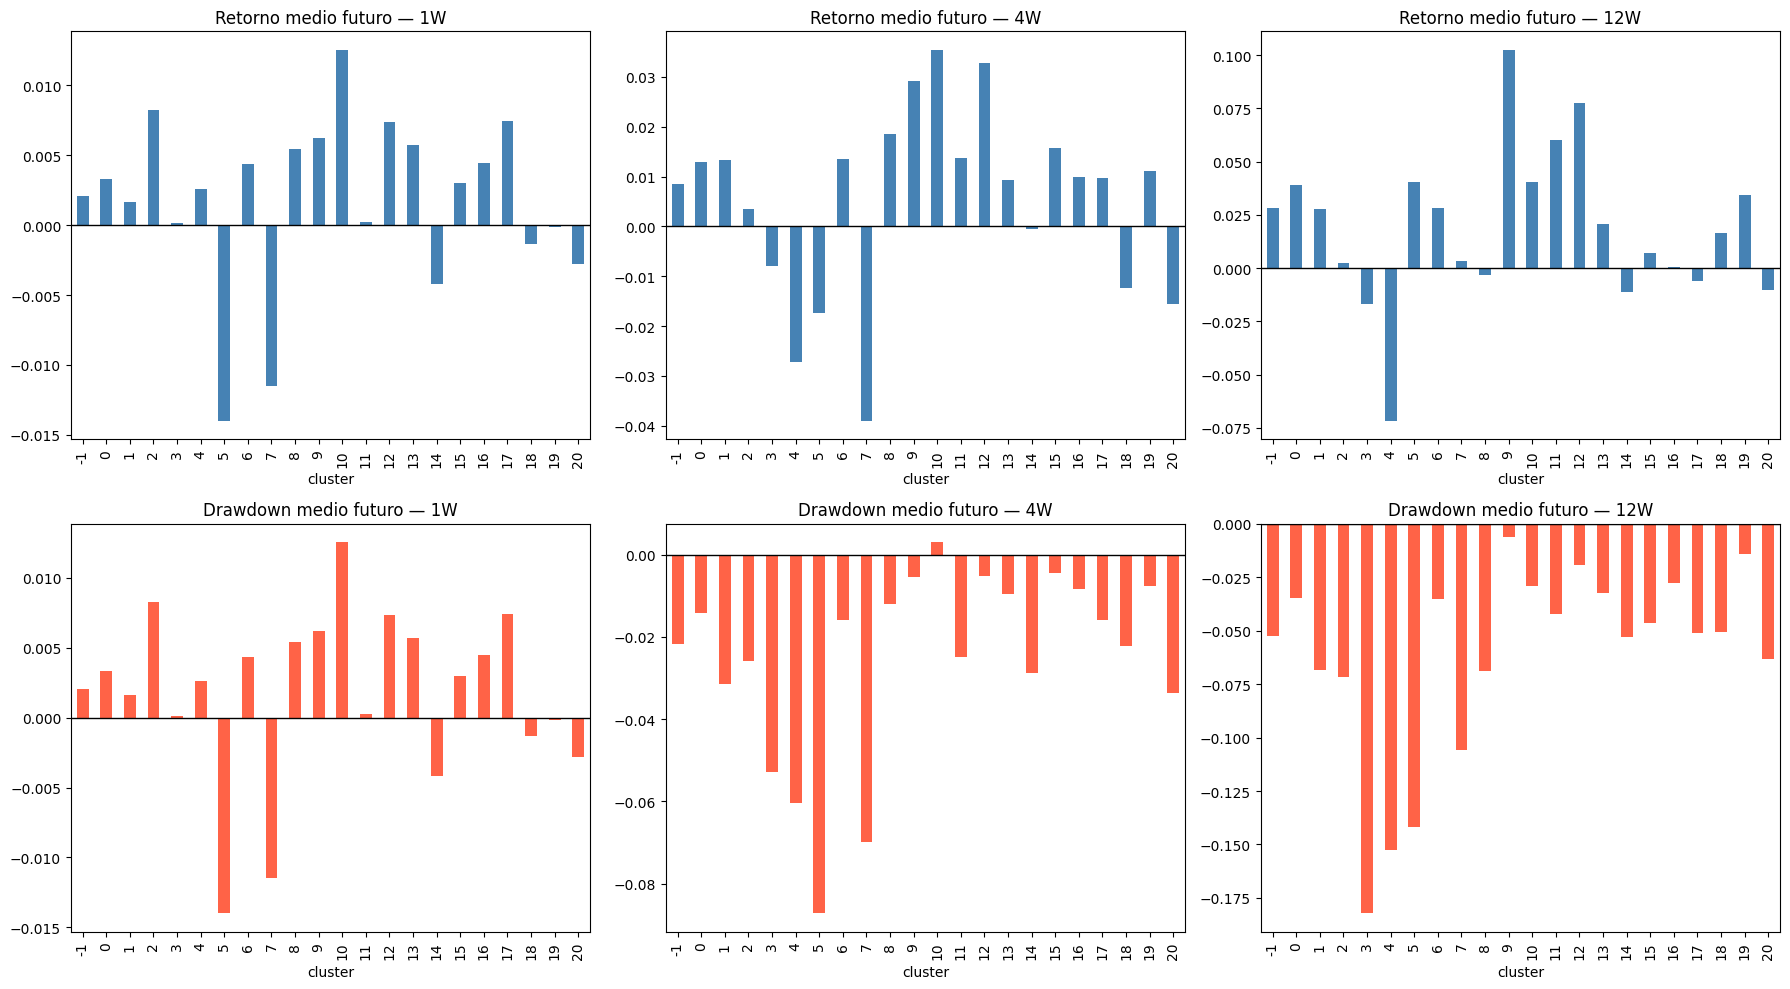

In [10]:
# =========================================================
# BLOQUE 8 — MÉTRICAS FUTURAS POR CLUSTER
# =========================================================

weekly_summary, weekly_with_forward = forward_metrics_summary(
    weekly_clust, cluster_col="cluster", horizons=(1, 4, 12)
)

# Añadir horizonte 24W al dataset
weekly_with_forward["fwd_ret_24"] = forward_return(weekly_with_forward["Close"], 24)
weekly_with_forward["fwd_dd_24"]  = forward_drawdown(weekly_with_forward["Close"], 24)

print("📊 RESUMEN POR CLUSTER (retornos y drawdowns futuros)")
display(weekly_summary.round(4))

# ─── Gráficos: retornos y drawdowns por cluster ──────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for col_i, h in enumerate([1, 4, 12]):
    # Retornos
    (weekly_with_forward.groupby("cluster")[f"fwd_ret_{h}"].mean()
     .sort_index().plot(kind="bar", ax=axes[0, col_i], color="steelblue"))
    axes[0, col_i].set_title(f"Retorno medio futuro — {h}W")
    axes[0, col_i].axhline(0, color="black", linewidth=1)

    # Drawdowns
    (weekly_with_forward.groupby("cluster")[f"fwd_dd_{h}"].mean()
     .sort_index().plot(kind="bar", ax=axes[1, col_i], color="tomato"))
    axes[1, col_i].set_title(f"Drawdown medio futuro — {h}W")
    axes[1, col_i].axhline(0, color="black", linewidth=1)

plt.tight_layout()
plt.show()


### BLOQUE 9 — Meta-estados: bull / neutral / stress / anomaly

Los clusters individuales son difíciles de interpretar y pueden variar entre
corridas. Los **meta-estados** los agrupan en 4 categorías económicamente
interpretables, usando un score que combina:

- Retorno futuro 12W (positivo = mejor)
- Drawdown futuro 12W (negativo = peor)
- Volatilidad (alta = peor)

> **bull** = mejor tercio de clusters por score  
> **stress** = peor tercio  
> **neutral** = el resto  
> **anomaly** = cluster -1 de HDBSCAN


📊 SCORE ECONÓMICO POR CLUSTER (mayor = mejor)


cluster
 5     1.7304
 9     1.2119
 3     1.1514
 12    0.7687
 7     0.4681
 11    0.4405
 10    0.2966
 18    0.1524
 0     0.1388
 19   -0.0525
-1    -0.1435
 15   -0.1527
 6    -0.2136
 13   -0.2314
 8    -0.2352
 1    -0.2939
 17   -0.4555
 2    -0.4901
 20   -0.5213
 14   -0.7634
 16   -0.7807
 4    -2.0251
Name: economic_score, dtype: float64


📊 META-ESTADOS — distribución
meta_state
neutral    709
stress     241
anomaly    201
bull       176

📊 META-SUMMARY


,count,mean_return,vol,mean_drawdown,mean_cluster_prob,fwd_ret_1,fwd_ret_4,fwd_ret_12,fwd_dd_1,fwd_dd_4,fwd_dd_12
meta_state,,,,,,,,,,,
anomaly,201,0.0055,0.0318,-0.5601,0.0000,0.0021,0.0085,0.0283,0.0021,-0.0216,-0.0525
stress,241,0.0045,0.0433,-0.5254,0.9300,0.0024,0.0044,0.0046,0.0024,-0.0303,-0.0705
neutral,709,0.0044,0.0214,-0.1828,0.9443,0.0033,0.0121,0.0339,0.0033,-0.0137,-0.0360
bull,176,-0.0112,0.0400,-0.4672,0.8350,0.0004,0.0102,0.0527,0.0004,-0.0329,-0.0674


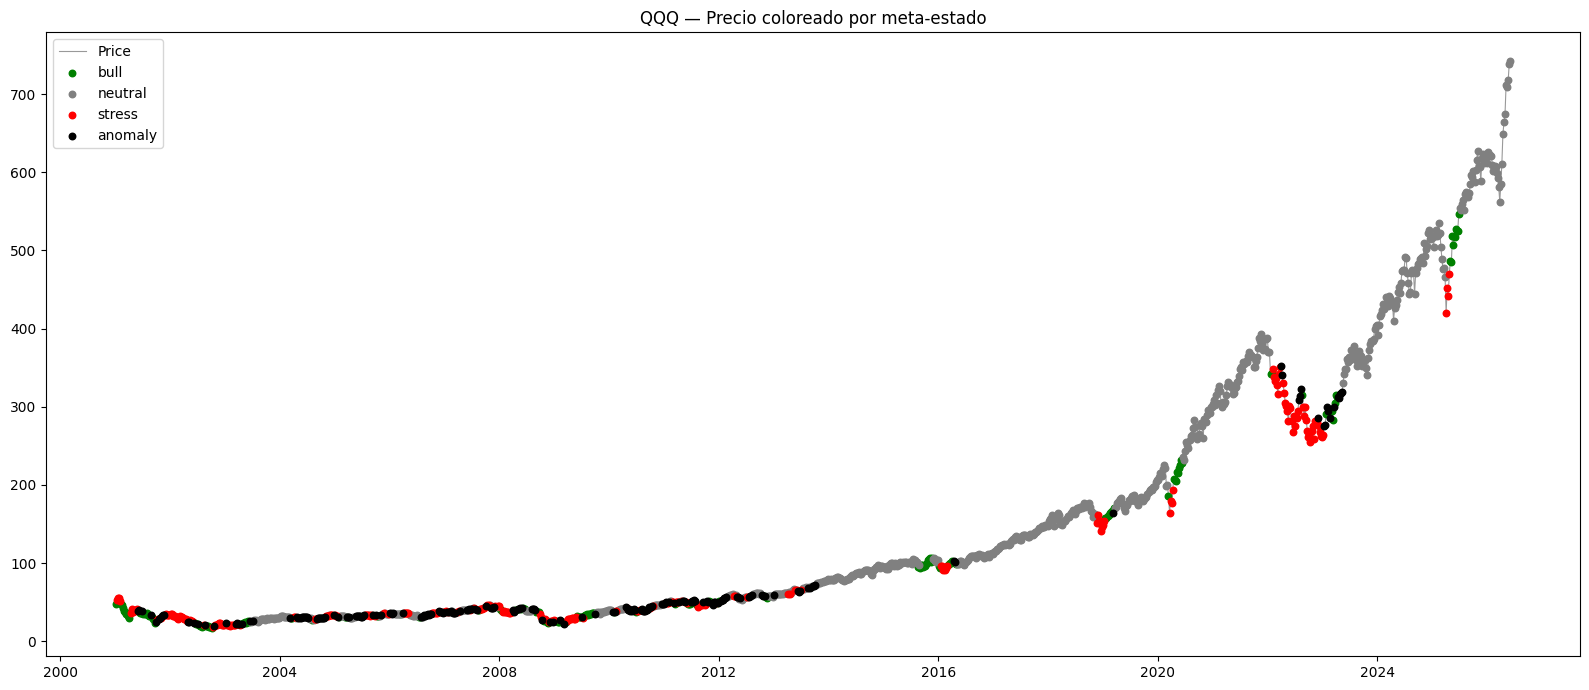


✅ final_weekly_structure listo: (1327, 48)


In [11]:
# =========================================================
# BLOQUE 9 — META-ESTADOS (bull / neutral / stress / anomaly)
# =========================================================

# ─── Score económico ─────────────────────────────────────
weekly_summary["economic_score"] = cluster_score(
    weekly_summary, ret_col="fwd_ret_12", dd_col="fwd_dd_12", vol_col="vol"
)
print("📊 SCORE ECONÓMICO POR CLUSTER (mayor = mejor)")
display(weekly_summary["economic_score"].sort_values(ascending=False).round(4))

# ─── Asignar etiquetas y propagar ────────────────────────
cluster_labels = assign_cluster_labels(weekly_summary)
weekly_with_forward["meta_state"] = weekly_with_forward["cluster"].map(cluster_labels)

print("\n📊 META-ESTADOS — distribución")
print(weekly_with_forward["meta_state"].value_counts().to_string())

# ─── Meta-summary ────────────────────────────────────────
meta_summary = (
    weekly_with_forward
    .groupby("meta_state")
    .agg(
        count             = ("returns",      "size"),
        mean_return       = ("returns",      "mean"),
        vol               = ("returns",      "std"),
        mean_drawdown     = ("drawdown",     "mean"),
        mean_cluster_prob = ("cluster_prob", "mean"),
        fwd_ret_1         = ("fwd_ret_1",    "mean"),
        fwd_ret_4         = ("fwd_ret_4",    "mean"),
        fwd_ret_12        = ("fwd_ret_12",   "mean"),
        fwd_dd_1          = ("fwd_dd_1",     "mean"),
        fwd_dd_4          = ("fwd_dd_4",     "mean"),
        fwd_dd_12         = ("fwd_dd_12",    "mean"),
    )
    .sort_values("mean_return", ascending=False)
)
print("\n📊 META-SUMMARY")
display(meta_summary.round(4))

# ─── Visualización: precio coloreado por meta-estado ─────
META_COLORS = {"bull": "green", "neutral": "gray", "stress": "red", "anomaly": "black"}

fig, ax = plt.subplots(figsize=(16, 7))
ax.plot(
    weekly_with_forward.index, weekly_with_forward["Close"],
    color="black", linewidth=0.8, alpha=0.4, label="Price"
)
for state, color in META_COLORS.items():
    mask = weekly_with_forward["meta_state"] == state
    if mask.any():
        ax.scatter(
            weekly_with_forward.index[mask],
            weekly_with_forward["Close"][mask],
            s=22, c=color, label=state, zorder=3
        )
ax.set_title("QQQ — Precio coloreado por meta-estado")
ax.legend()
plt.tight_layout()
plt.show()

# ─── Dataset final de esta parte ─────────────────────────
final_weekly_structure = weekly_with_forward.copy()
print(f"\n✅ final_weekly_structure listo: {final_weekly_structure.shape}")


---
## 🤖 Parte 3 — Forecast Supervisado: XGBoost Regime Forecast
### BLOQUE 10 — Modelo de clasificación de régimen futuro

**Objetivo:** predecir si, en `FUTURE_HORIZON` semanas, el mercado estará en
régimen `bull` o `stress`.

**Decisiones de diseño:**
- Excluimos `neutral` y `anomaly` del target para tener una clasificación
  binaria más limpia y accionable.
- Agregamos features de **dinámica temporal** (cambios en momentum, volatilidad,
  cluster_prob) que capturan aceleración/desaceleración del mercado.
- Split **temporal** (sin shuffle): 70% entrenamiento, 30% prueba. Esto es
  crítico para evitar lookahead bias.

**Sobre la regularización:** usamos `reg_alpha`, `reg_lambda`, `subsample` y
`colsample_bytree` moderados para controlar overfitting desde el inicio.


In [12]:
# =========================================================
# BLOQUE 10 — MODELO XGBoost: RÉGIMEN FUTURO
# =========================================================

df = final_weekly_structure.copy()

# ─── Target: régimen en 4 semanas ────────────────────────
df["future_meta_state"] = df["meta_state"].shift(-FUTURE_HORIZON)
df_model = df[df["future_meta_state"].isin(["bull", "stress"])].copy()
df_model["target"] = df_model["future_meta_state"].map({"stress": 0, "bull": 1})

print(f"Filas bull/stress: {len(df_model)}")
print(f"  → Bull   : {df_model['target'].sum():4d} ({df_model['target'].mean():.1%})")
print(f"  → Stress : {(df_model['target']==0).sum():4d} ({(df_model['target']==0).mean():.1%})")

# ─── Features adicionales de dinámica temporal ───────────
df_model["mom_13_delta"]        = df_model["mom_13"].diff()
df_model["vol_13_change"]       = df_model["vol_13"].pct_change()
df_model["trend_change"]        = df_model["trend_13_52"].diff()
df_model["cluster_prob_change"] = df_model["cluster_prob"].diff()
df_model["same_state"]          = (df_model["meta_state"] == df_model["meta_state"].shift(1)).astype(int)
df_model["mom_13_roll_mean"]    = df_model["mom_13"].rolling(4).mean()
df_model["vol_13_roll_mean"]    = df_model["vol_13"].rolling(4).mean()
df_model["drawdown_change"]     = df_model["drawdown"].diff()

MODEL_FEATURES = [
    # Retornos y volatilidad
    "returns", "vol_4", "vol_13", "vol_26",
    # Momentum
    "mom_4", "mom_13", "mom_26", "mom_52",
    # Tendencia
    "trend_13_52", "price_vs_sma_52", "sma13_slope",
    # Breakouts
    "breakout_13", "breakout_26", "breakdown_13",
    # Riesgo
    "atr_pct", "drawdown",
    # Estructura
    "cluster_prob",
    # Dinámica temporal
    "mom_13_delta", "vol_13_change", "trend_change",
    "cluster_prob_change", "same_state",
    "mom_13_roll_mean", "vol_13_roll_mean", "drawdown_change",
]

df_model = df_model.dropna(subset=MODEL_FEATURES + ["target"]).copy()

# ─── Split temporal ───────────────────────────────────────
split_idx = int(len(df_model) * (1 - TEST_SIZE))
X_train = df_model[MODEL_FEATURES].iloc[:split_idx]
X_test  = df_model[MODEL_FEATURES].iloc[split_idx:]
y_train = df_model["target"].iloc[:split_idx]
y_test  = df_model["target"].iloc[split_idx:]

print(f"\nTrain: {len(X_train)} obs  |  Test: {len(X_test)} obs")
print(f"Período test: {df_model.index[split_idx].date()} → {df_model.index[-1].date()}")

# ─── Modelo ───────────────────────────────────────────────
model = XGBClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.5,
    reg_lambda=2.0,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)
model.fit(X_train, y_train)

# ─── Predicciones ────────────────────────────────────────
train_probs = model.predict_proba(X_train)[:, 1]
test_probs  = model.predict_proba(X_test)[:, 1]
test_preds  = (test_probs > 0.5).astype(int)

# ─── Métricas ────────────────────────────────────────────
print(f"\n🎯 MÉTRICAS")
print(f"  Train AUC : {roc_auc_score(y_train, train_probs):.4f}")
print(f"  Test  AUC : {roc_auc_score(y_test,  test_probs):.4f}")
print(f"\n{classification_report(y_test, test_preds, target_names=['stress','bull'])}")


Filas bull/stress: 413
  → Bull   :  175 (42.4%)
  → Stress :  238 (57.6%)

Train: 287 obs  |  Test: 123 obs
Período test: 2015-07-24 → 2025-05-30

🎯 MÉTRICAS
  Train AUC : 0.9949
  Test  AUC : 0.6237

              precision    recall  f1-score   support

      stress       0.60      0.88      0.71        64
        bull       0.73      0.37      0.49        59

    accuracy                           0.63       123
   macro avg       0.67      0.62      0.60       123
weighted avg       0.67      0.63      0.61       123



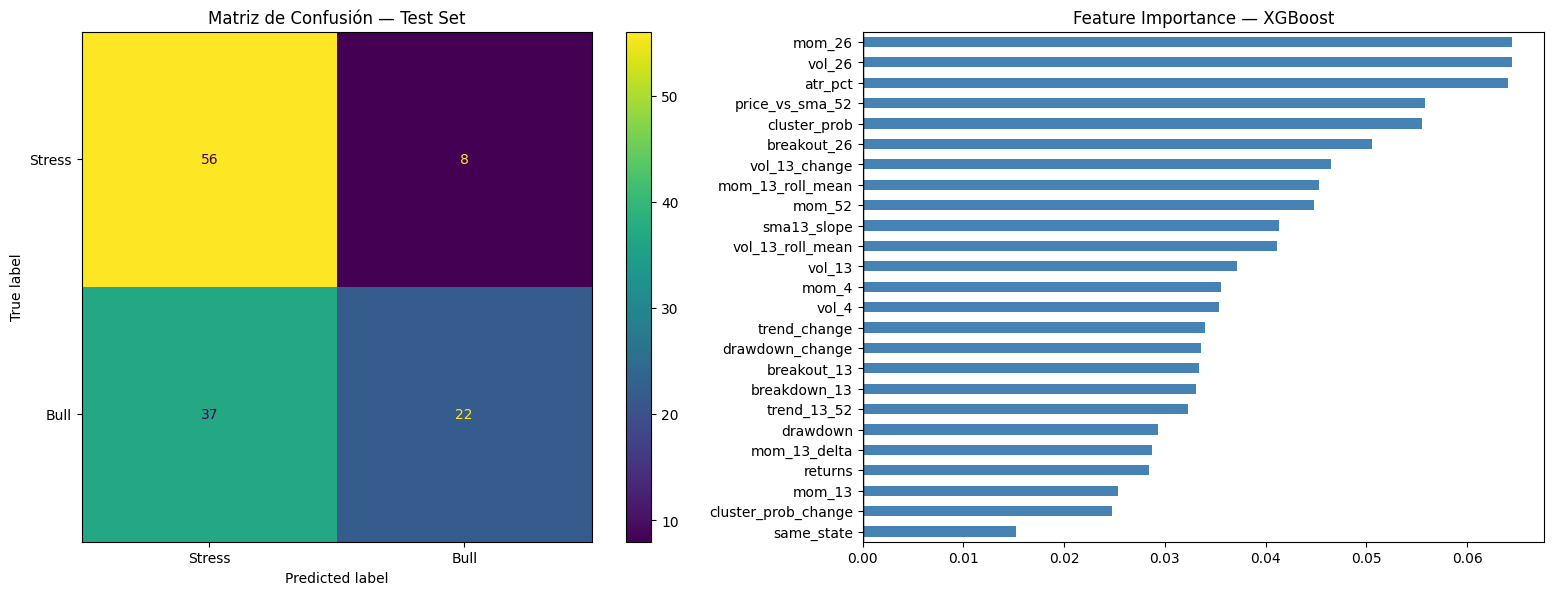

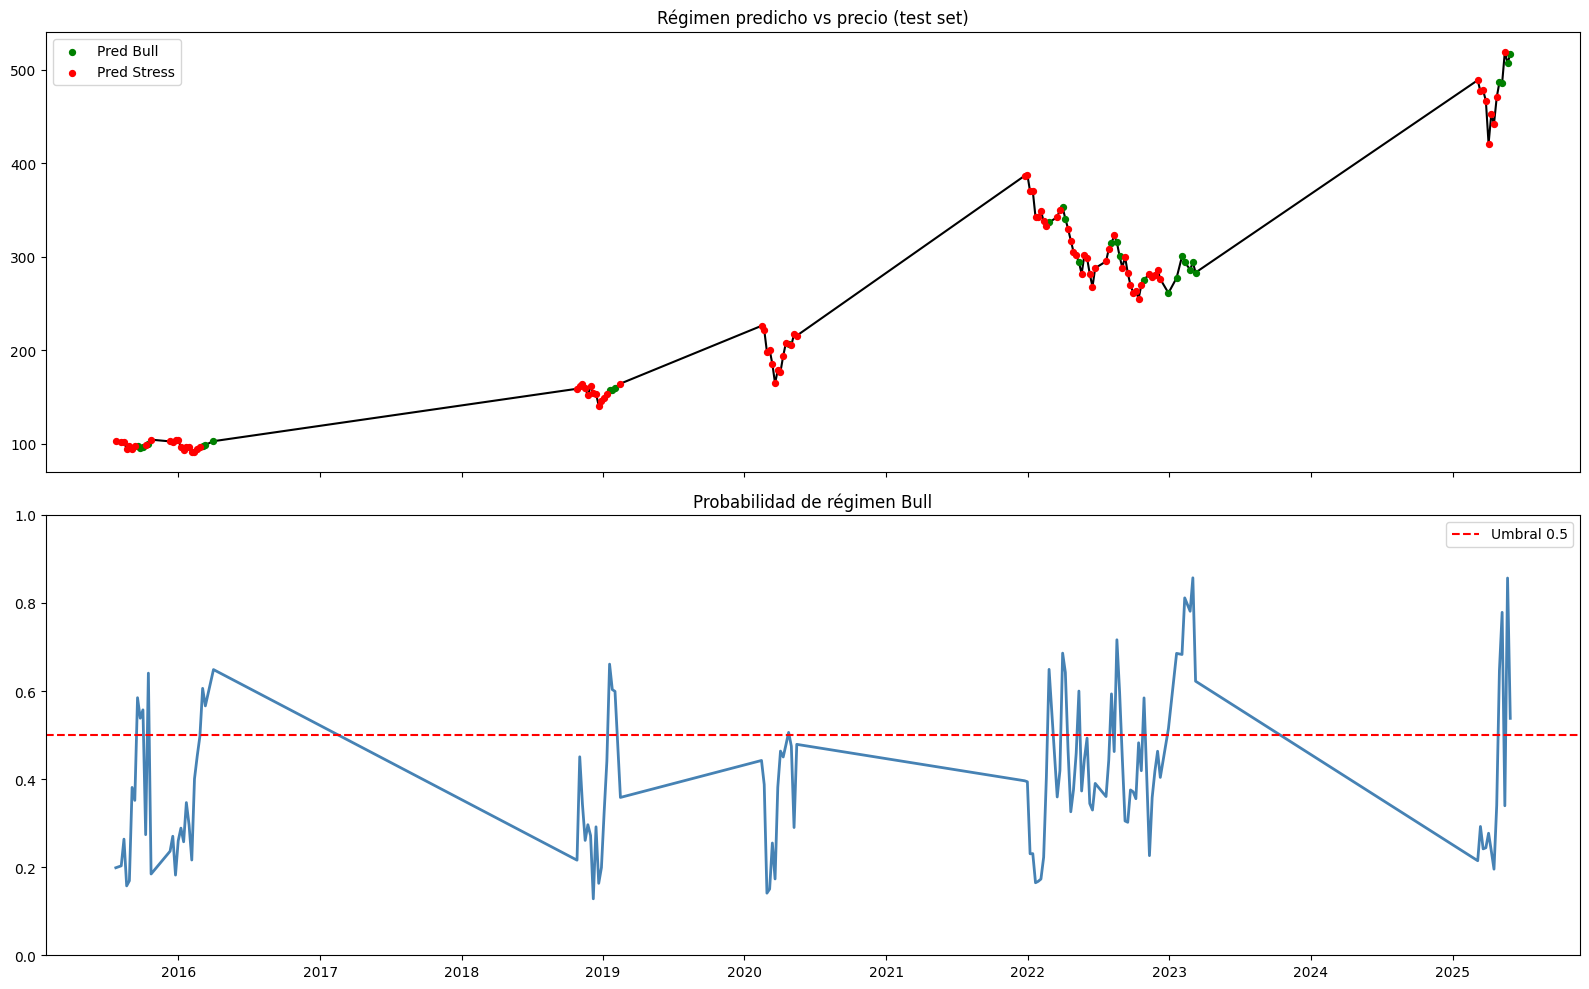


✅ pred_prob_bull exportado: 410 filas


In [13]:
# ─── Confusion matrix ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cm = confusion_matrix(y_test, test_preds)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Stress","Bull"]).plot(ax=axes[0])
axes[0].set_title("Matriz de Confusión — Test Set")

# ─── Feature importance ──────────────────────────────────
importance = pd.Series(
    model.feature_importances_, index=MODEL_FEATURES
).sort_values(ascending=True)

importance.plot(kind="barh", ax=axes[1], color="steelblue")
axes[1].set_title("Feature Importance — XGBoost")
axes[1].axvline(0, color="black", linewidth=1)

plt.tight_layout()
plt.show()

# ─── Resultados temporales ───────────────────────────────
results = df_model.iloc[split_idx:].copy()
results["pred_prob_bull"] = test_probs
results["pred_state"]     = np.where(test_probs > 0.5, "bull", "stress")
results["real_state"]     = np.where(y_test == 1, "bull", "stress")

fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

axes[0].plot(results.index, results["Close"], color="black", linewidth=1.5)
axes[0].scatter(results.index[results["pred_state"]=="bull"],
                results["Close"][results["pred_state"]=="bull"],
                color="green", s=18, label="Pred Bull", zorder=3)
axes[0].scatter(results.index[results["pred_state"]=="stress"],
                results["Close"][results["pred_state"]=="stress"],
                color="red", s=18, label="Pred Stress", zorder=3)
axes[0].set_title("Régimen predicho vs precio (test set)")
axes[0].legend()

axes[1].plot(results.index, results["pred_prob_bull"], linewidth=2, color="steelblue")
axes[1].axhline(0.5, color="red", linestyle="--", label="Umbral 0.5")
axes[1].set_title("Probabilidad de régimen Bull")
axes[1].set_ylim(0, 1)
axes[1].legend()

plt.tight_layout()
plt.show()

# ─── Exportar pred_prob_bull al dataset principal ────────
all_probs = model.predict_proba(df_model[MODEL_FEATURES])[:, 1]
df_model_export = df_model.copy()
df_model_export["pred_prob_bull"] = all_probs
final_weekly_structure["pred_prob_bull"] = df_model_export["pred_prob_bull"]

print(f"\n✅ pred_prob_bull exportado: {final_weekly_structure['pred_prob_bull'].notna().sum()} filas")


---
## 📐 Parte 4 — Calibración y Cobertura del Forecast
### BLOQUE 11 — Calibración: ¿son confiables las probabilidades?

Un modelo bien calibrado produce probabilidades que se corresponden con
frecuencias observadas. Si dice 0.8, debería ocurrir bull ~80% de las veces.

**Expected Calibration Error (ECE):** cercano a 0 = bien calibrado.
Un modelo puede tener buen AUC pero mala calibración. Ambas cosas importan.


📊 TABLA DE CALIBRACIÓN


,prob_bin,pred_prob,actual_rate,count
0,"(-0.001, 0.1]",0.0755,0.0000,28
1,"(0.1, 0.2]",0.1522,0.1429,56
2,"(0.2, 0.3]",0.2500,0.1667,54
3,"(0.3, 0.4]",0.3515,0.3448,29
4,"(0.4, 0.5]",0.4513,0.5000,24
5,"(0.5, 0.6]",0.5656,0.6364,11
6,"(0.6, 0.7]",0.6590,0.6471,17
7,"(0.7, 0.8]",0.7524,0.8000,20
8,"(0.8, 0.9]",0.8487,0.9643,28
9,"(0.9, 1.0]",0.9452,1.0000,1



Expected Calibration Error (ECE): 0.0512
(0 = calibración perfecta | >0.10 = sobreestimación importante)


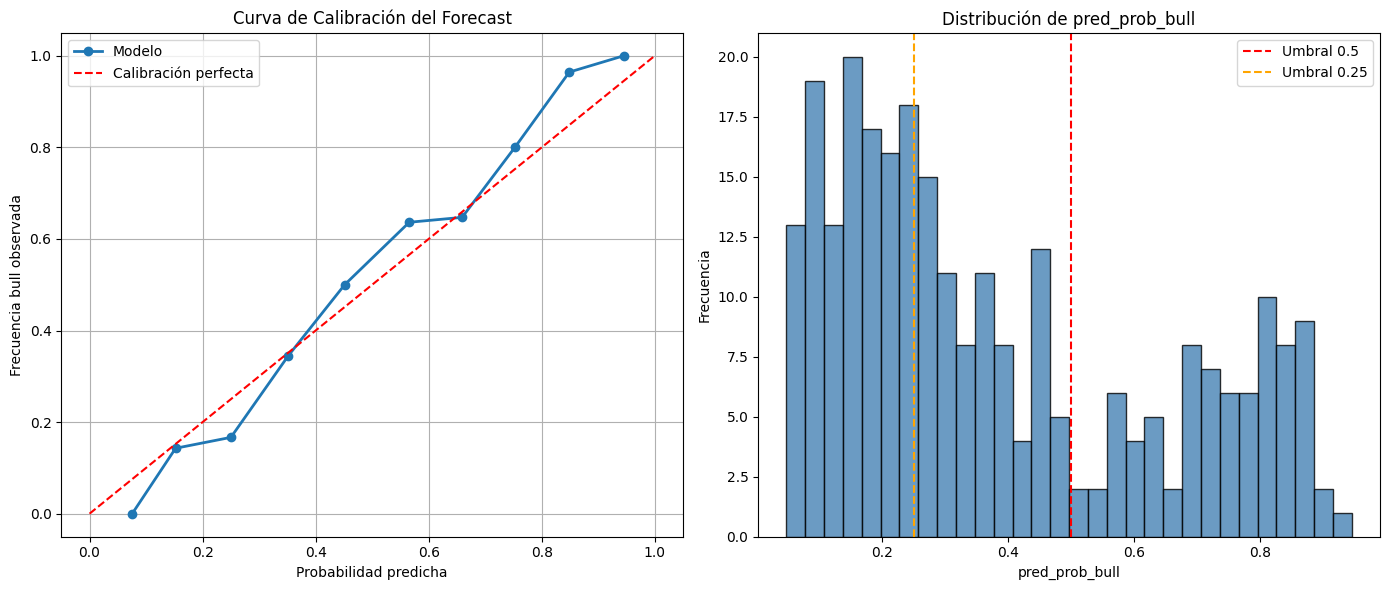

In [14]:
# =========================================================
# BLOQUE 11 — CALIBRACIÓN DEL FORECAST
# =========================================================

df_cal = final_weekly_structure.dropna(subset=["pred_prob_bull"]).copy()
df_cal["future_meta_state"] = df_cal["meta_state"].shift(-FUTURE_HORIZON)
df_cal = df_cal[df_cal["future_meta_state"].isin(["bull", "stress"])].copy()
df_cal["target"] = df_cal["future_meta_state"].map({"stress": 0, "bull": 1})

# ─── Bins de probabilidad ────────────────────────────────
df_cal["prob_bin"] = pd.cut(
    df_cal["pred_prob_bull"],
    bins=np.arange(0, 1.1, 0.1),
    include_lowest=True
)

calibration = (
    df_cal.groupby("prob_bin", observed=True)
    .agg(
        pred_prob   = ("pred_prob_bull", "mean"),
        actual_rate = ("target",         "mean"),
        count       = ("target",         "count")
    )
    .reset_index()
)

print("📊 TABLA DE CALIBRACIÓN")
display(calibration.round(4))

# ─── Error de calibración (ECE) ──────────────────────────
ece = (
    (calibration["pred_prob"] - calibration["actual_rate"]).abs()
    * calibration["count"]
).sum() / calibration["count"].sum()
print(f"\nExpected Calibration Error (ECE): {ece:.4f}")
print("(0 = calibración perfecta | >0.10 = sobreestimación importante)")

# ─── Gráficos ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].plot(calibration["pred_prob"], calibration["actual_rate"],
             marker="o", linewidth=2, label="Modelo")
axes[0].plot([0, 1], [0, 1], linestyle="--", color="red", label="Calibración perfecta")
axes[0].set_title("Curva de Calibración del Forecast")
axes[0].set_xlabel("Probabilidad predicha")
axes[0].set_ylabel("Frecuencia bull observada")
axes[0].legend()
axes[0].grid(True)

axes[1].hist(df_cal["pred_prob_bull"], bins=30, edgecolor="black", alpha=0.8, color="steelblue")
axes[1].axvline(0.5, color="red",    linestyle="--", label="Umbral 0.5")
axes[1].axvline(0.25, color="orange",linestyle="--", label="Umbral 0.25")
axes[1].set_title("Distribución de pred_prob_bull")
axes[1].set_xlabel("pred_prob_bull")
axes[1].set_ylabel("Frecuencia")
axes[1].legend()

plt.tight_layout()
plt.show()


### BLOQUE 12 — Cobertura: ¿qué pasa al subir el umbral de entrada?

Al aumentar el umbral (de 0.10 a 0.90), filtramos más agresivamente:
- La **cobertura** baja (menos semanas activas).
- La **bull rate observada** sube (más precisión).
- El **retorno promedio** puede subir o bajar dependiendo de si el modelo realmente distingue.

Este análisis justifica qué umbral usar en el backtest.


📊 COBERTURA VS UMBRAL


,threshold,count,coverage,bull_rate,avg_fwd_ret_12,hit_rate_12w
0,0.1,240,0.8955,0.4208,0.0072,0.5625
1,0.2,184,0.6866,0.5054,0.0044,0.5489
2,0.3,130,0.4851,0.6462,-0.0163,0.5000
3,0.4,101,0.3769,0.7327,-0.0286,0.4950
4,0.5,77,0.2873,0.8052,-0.0293,0.4805
5,0.6,66,0.2463,0.8333,-0.0354,0.4697
6,0.7,49,0.1828,0.8980,-0.0628,0.4082
7,0.8,29,0.1082,0.9655,-0.0612,0.3793
8,0.9,1,0.0037,1.0000,-0.2665,0.0000


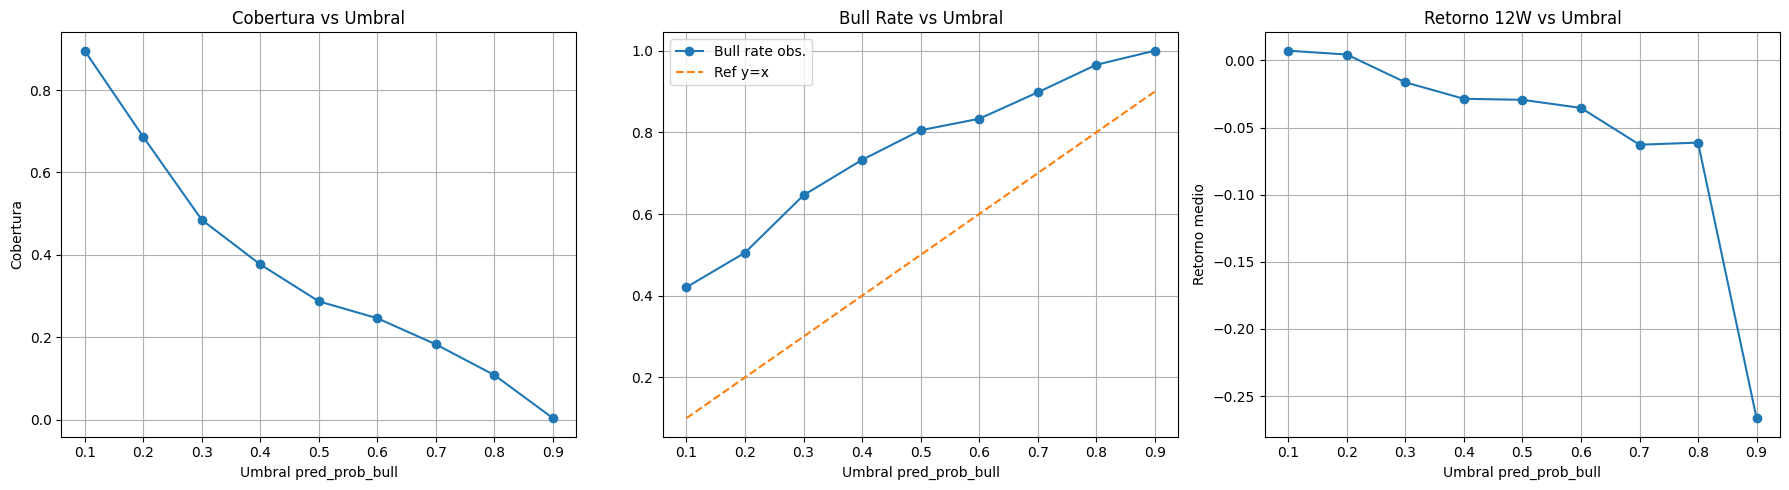

In [15]:
# =========================================================
# BLOQUE 12 — COBERTURA VS UMBRAL DEL FORECAST
# =========================================================

df_cov = final_weekly_structure.dropna(subset=["pred_prob_bull"]).copy()
df_cov["future_meta_state"] = df_cov["meta_state"].shift(-FUTURE_HORIZON)
df_cov = df_cov[df_cov["future_meta_state"].isin(["bull", "stress"])].copy()
df_cov["target"] = df_cov["future_meta_state"].map({"stress": 0, "bull": 1})
if "fwd_ret_12" not in df_cov.columns:
    df_cov["fwd_ret_12"] = df_cov["Close"].shift(-12) / df_cov["Close"] - 1

thresholds = np.arange(0.10, 1.00, 0.10)
rows = []
for thr in thresholds:
    sub = df_cov[df_cov["pred_prob_bull"] >= thr]
    if len(sub) == 0:
        continue
    rows.append({
        "threshold":      round(thr, 2),
        "count":          len(sub),
        "coverage":       len(sub) / len(df_cov),
        "bull_rate":      sub["target"].mean(),
        "avg_fwd_ret_12": sub["fwd_ret_12"].mean(),
        "hit_rate_12w":  (sub["fwd_ret_12"] > 0).mean(),
    })

cov_table = pd.DataFrame(rows)
print("📊 COBERTURA VS UMBRAL")
display(cov_table.round(4))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(cov_table["threshold"], cov_table["coverage"], marker="o")
axes[0].set_title("Cobertura vs Umbral")
axes[0].set_ylabel("Cobertura"); axes[0].grid(True)

axes[1].plot(cov_table["threshold"], cov_table["bull_rate"],    marker="o", label="Bull rate obs.")
axes[1].plot(cov_table["threshold"], cov_table["threshold"], linestyle="--", label="Ref y=x")
axes[1].set_title("Bull Rate vs Umbral"); axes[1].legend(); axes[1].grid(True)

axes[2].plot(cov_table["threshold"], cov_table["avg_fwd_ret_12"], marker="o")
axes[2].set_title("Retorno 12W vs Umbral")
axes[2].set_ylabel("Retorno medio"); axes[2].grid(True)

for ax in axes:
    ax.set_xlabel("Umbral pred_prob_bull")

plt.tight_layout()
plt.show()


---
## 🔬 Parte 5 — Anatomía de los Regímenes
### BLOQUE 13 — Estadísticas por régimen

¿Cómo se comporta el mercado dentro de cada meta-estado?
Miramos distribución de retornos (media, mediana), volatilidad, asimetría
(skewness) y colas (kurtosis).

- **Skew positivo:** las ganancias extremas son más grandes que las pérdidas extremas.
- **Kurtosis alta:** hay más eventos extremos de lo que esperaría una distribución normal.


📊 ESTADÍSTICAS DISTRIBUCIONALES POR RÉGIMEN


,regime,count,avg_return,median_return,volatility,skew,kurtosis,best_week,worst_week
0,anomaly,201,0.0055,0.0068,0.0318,-0.4388,1.3546,0.0795,-0.1343
3,stress,241,0.0045,0.0009,0.0433,0.5123,1.4208,0.1905,-0.1193
2,neutral,709,0.0044,0.0050,0.0214,-0.2594,1.4121,0.0937,-0.1063
1,bull,176,-0.0111,-0.0056,0.0401,-0.5348,0.5825,0.0756,-0.1733


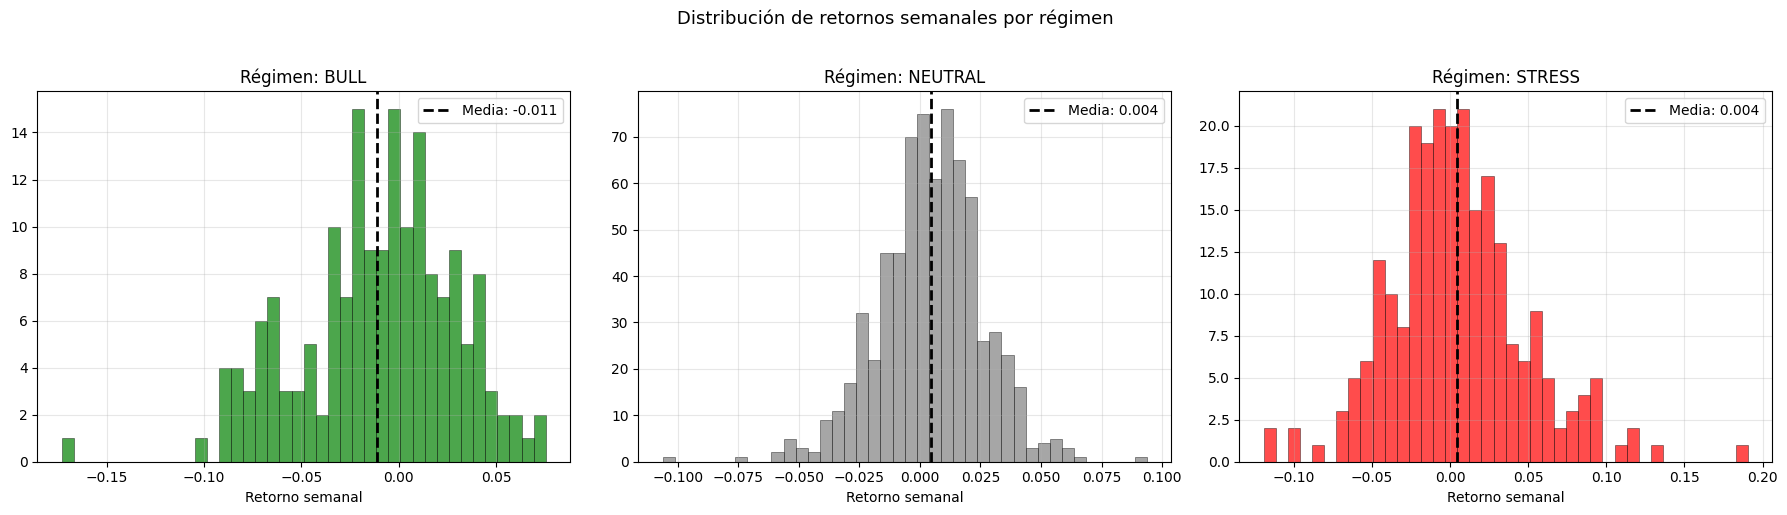

In [16]:
# =========================================================
# BLOQUE 13 — ESTADÍSTICAS POR RÉGIMEN
# =========================================================

df = final_weekly_structure.copy()
df["ret_1w"] = df["Close"].pct_change()

results = []
for regime, grp in df.groupby("meta_state"):
    rets = grp["ret_1w"].dropna()
    results.append({
        "regime":        regime,
        "count":         len(grp),
        "avg_return":    rets.mean(),
        "median_return": rets.median(),
        "volatility":    rets.std(),
        "skew":          skew(rets),
        "kurtosis":      kurtosis(rets),
        "best_week":     rets.max(),
        "worst_week":    rets.min(),
    })

regime_stats = pd.DataFrame(results).sort_values("avg_return", ascending=False)
print("📊 ESTADÍSTICAS DISTRIBUCIONALES POR RÉGIMEN")
display(regime_stats.round(4))

# ─── Distribución de retornos por régimen ────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)
colors = {"bull": "green", "neutral": "gray", "stress": "red"}

for i, (regime, color) in enumerate(colors.items()):
    rets = df[df["meta_state"] == regime]["ret_1w"].dropna()
    axes[i].hist(rets, bins=40, color=color, alpha=0.7, edgecolor="black", linewidth=0.4)
    axes[i].axvline(rets.mean(), color="black", linestyle="--", linewidth=2, label=f"Media: {rets.mean():.3f}")
    axes[i].set_title(f"Régimen: {regime.upper()}")
    axes[i].set_xlabel("Retorno semanal")
    axes[i].legend()
    axes[i].grid(alpha=0.3)

plt.suptitle("Distribución de retornos semanales por régimen", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


### BLOQUE 14 — Duración y bloques de régimen

¿Cuánto dura cada régimen? ¿Con qué frecuencia cambia?
Calculamos la duración media de cada episodio de régimen continuo.


📊 DURACIÓN DE EPISODIOS POR RÉGIMEN (semanas)


,meta_state,avg_duration,median_duration,max_duration,episodes
0,anomaly,2.1,1.0,9,96
1,bull,3.0,2.0,12,58
2,neutral,12.4,2.0,133,57
3,stress,3.3,2.0,22,73



📊 TOP 20 EPISODIOS MÁS LARGOS


,regime_block,meta_state,start_date,end_date,duration_weeks
252,253,neutral,2016-05-06,2018-11-16,133
280,281,neutral,2023-05-19,2025-03-28,98
242,243,neutral,2013-10-11,2015-08-14,97
261,262,neutral,2020-06-19,2022-01-14,83
257,258,neutral,2019-03-22,2020-03-06,51
283,284,neutral,2025-07-04,2026-06-05,49
38,39,neutral,2003-07-11,2004-03-05,35
15,16,stress,2001-11-30,2002-04-26,22
158,159,neutral,2009-10-09,2010-01-22,16
265,266,stress,2022-04-15,2022-07-22,15


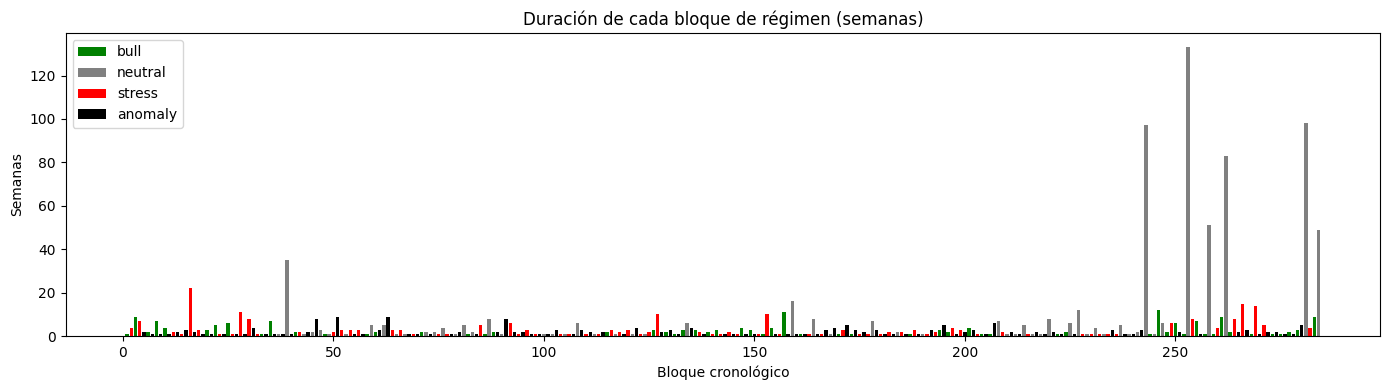

In [17]:
# =========================================================
# BLOQUE 14 — DURACIÓN Y BLOQUES DE RÉGIMEN
# =========================================================

df = final_weekly_structure.copy()

df["regime_change"] = (df["meta_state"] != df["meta_state"].shift())
df["regime_block"]  = df["regime_change"].cumsum()

durations = (
    df.groupby(["regime_block", "meta_state"])
    .size()
    .reset_index(name="duration_weeks")
)

duration_stats = (
    durations.groupby("meta_state")
    .agg(
        avg_duration    = ("duration_weeks", "mean"),
        median_duration = ("duration_weeks", "median"),
        max_duration    = ("duration_weeks", "max"),
        episodes        = ("duration_weeks", "size"),
    )
    .reset_index()
)

print("📊 DURACIÓN DE EPISODIOS POR RÉGIMEN (semanas)")
display(duration_stats.round(1))

# ─── Bloques históricos con fechas ───────────────────────
tmp = df.reset_index()
blocks = (
    tmp.groupby(["regime_block", "meta_state"])
    .agg(
        start_date      = ("Date", "first"),
        end_date        = ("Date", "last"),
        duration_weeks  = ("Date", "size"),
    )
    .reset_index()
    .sort_values("duration_weeks", ascending=False)
)

print("\n📊 TOP 20 EPISODIOS MÁS LARGOS")
display(blocks.head(20))

# ─── Gráfico de duración por bloque ──────────────────────
plt.figure(figsize=(14, 4))
color_map = {"bull": "green", "neutral": "gray", "stress": "red", "anomaly": "black"}
bar_colors = [color_map.get(r, "blue") for r in blocks.sort_values("regime_block")["meta_state"]]
plt.bar(
    blocks.sort_values("regime_block")["regime_block"],
    blocks.sort_values("regime_block")["duration_weeks"],
    color=bar_colors
)
plt.title("Duración de cada bloque de régimen (semanas)")
plt.xlabel("Bloque cronológico")
plt.ylabel("Semanas")
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=s) for s, c in color_map.items()]
plt.legend(handles=legend_elements)
plt.tight_layout()
plt.show()


### BLOQUE 15 — Estudio de transiciones: Stress → Bull

Las transiciones de régimen son momentos de alta información. Analizamos:
- Qué señales se activan **antes** de una transición Stress → Bull.
- Cómo evolucionan los retornos futuros conforme nos acercamos al cambio de régimen.


Eventos Stress → Bull encontrados: 15


,date,meta_state,prev_regime
Date,,,
2001-02-09,2001-02-09,bull,stress
2003-04-18,2003-04-18,bull,stress
2006-05-12,2006-05-12,bull,stress
2008-01-04,2008-01-04,bull,stress
2008-11-07,2008-11-07,bull,stress
2009-01-09,2009-01-09,bull,stress
2009-03-20,2009-03-20,bull,stress
2009-06-05,2009-06-05,bull,stress
2009-07-17,2009-07-17,bull,stress



📊 SEÑALES Y RETORNOS MEDIOS ANTES DE LA TRANSICIÓN


,weeks_before,pred_prob_bull,ret_4w,ret_12w,ret_24w
4,12,0.4402,-0.0054,-0.0090,0.0850
3,8,0.3553,-0.0425,0.0273,0.0890
2,4,0.5331,0.0348,0.0557,0.1758
1,1,0.5516,0.0120,0.0584,0.1367
0,0,0.5868,0.0156,0.0725,0.1350


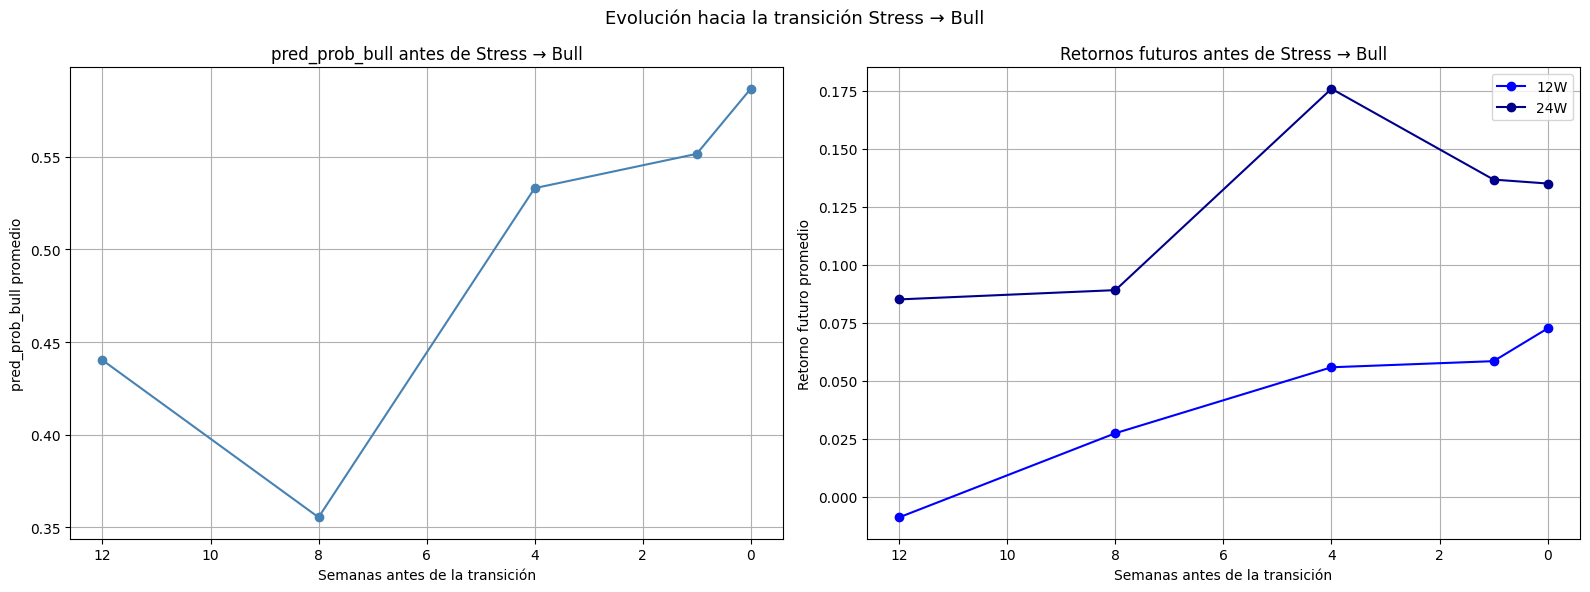

In [18]:
# =========================================================
# BLOQUE 15 — ESTUDIO DE TRANSICIONES (Stress → Bull)
# =========================================================

df = final_weekly_structure.copy()
for h in [4, 12, 24]:
    if f"fwd_ret_{h}" not in df.columns:
        df[f"fwd_ret_{h}"] = df["Close"].shift(-h) / df["Close"] - 1

df["prev_regime"] = df["meta_state"].shift(1)
events = df[(df["prev_regime"] == "stress") & (df["meta_state"] == "bull")].copy()
events["transition"] = df["prev_regime"].fillna("START") + " -> " + df["meta_state"]

print(f"Eventos Stress → Bull encontrados: {len(events)}")
events["date"] = events.index
display(events[["date", "meta_state", "prev_regime"]].head(10))

# ─── Ventanas previas a cada transición ──────────────────
windows = [12, 8, 4, 1, 0]
rows = []
for event_date in events.index:
    event_loc = df.index.get_loc(event_date)
    for w in windows:
        idx = event_loc - w
        if idx < 0:
            continue
        obs = df.iloc[idx]
        rows.append({
            "event_date":    event_date,
            "weeks_before":  w,
            "meta_state":    obs["meta_state"],
            "pred_prob_bull":obs.get("pred_prob_bull", np.nan),
            "ret_4w":        obs.get("fwd_ret_4",  np.nan),
            "ret_12w":       obs.get("fwd_ret_12", np.nan),
            "ret_24w":       obs.get("fwd_ret_24", np.nan),
        })

pre_trans = pd.DataFrame(rows)

summary_trans = (
    pre_trans.groupby("weeks_before")
    .agg(
        pred_prob_bull = ("pred_prob_bull", "mean"),
        ret_4w         = ("ret_4w",         "mean"),
        ret_12w        = ("ret_12w",        "mean"),
        ret_24w        = ("ret_24w",        "mean"),
    )
    .reset_index()
    .sort_values("weeks_before", ascending=False)
)

print("\n📊 SEÑALES Y RETORNOS MEDIOS ANTES DE LA TRANSICIÓN")
display(summary_trans.round(4))

# ─── Gráfico ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(summary_trans["weeks_before"], summary_trans["pred_prob_bull"], marker="o", color="steelblue")
axes[0].set_title("pred_prob_bull antes de Stress → Bull")
axes[0].set_xlabel("Semanas antes de la transición")
axes[0].set_ylabel("pred_prob_bull promedio")
axes[0].invert_xaxis()
axes[0].grid(True)

axes[1].plot(summary_trans["weeks_before"], summary_trans["ret_12w"], marker="o", label="12W", color="blue")
axes[1].plot(summary_trans["weeks_before"], summary_trans["ret_24w"], marker="o", label="24W", color="darkblue")
axes[1].set_title("Retornos futuros antes de Stress → Bull")
axes[1].set_xlabel("Semanas antes de la transición")
axes[1].set_ylabel("Retorno futuro promedio")
axes[1].invert_xaxis()
axes[1].legend()
axes[1].grid(True)

plt.suptitle("Evolución hacia la transición Stress → Bull", fontsize=13)
plt.tight_layout()
plt.show()


---
## 📡 Parte 6 — Señales Técnicas
### BLOQUE 16 — Definición de señales (RSI, BB, SMA, MOM, BULL, CONF)

Definimos **todas las señales técnicas aquí una sola vez** y las exportamos al
dataset principal. Los bloques siguientes solo usan `final_weekly_structure`.

| Señal | Tipo | Descripción |
|-------|------|-------------|
| `feat_rsi` | Mean-reversion | RSI(14) < 30 — sobreventa |
| `feat_bb` | Mean-reversion | Precio bajo la banda inferior Bollinger (20, 2σ) |
| `feat_sma` | Trend-following | SMA20 > SMA50 — tendencia alcista |
| `feat_mom` | Momentum | Momentum 63 semanas positivo |
| `feat_bull` | ML Forecast | pred_prob_bull > 0.50 |
| `feat_conf` | Confianza ML | pred_prob_bull alejado >0.40 de 0.5 (alta certeza) |


In [19]:
# =========================================================
# BLOQUE 16 — SEÑALES TÉCNICAS (definición única)
# =========================================================

df = final_weekly_structure.copy()

# ─── RSI 14 ──────────────────────────────────────────────
delta    = df["Close"].diff()
gain     = delta.clip(lower=0)
loss     = -delta.clip(upper=0)
rs       = gain.rolling(14).mean() / loss.rolling(14).mean()
df["rsi14"]    = 100 - (100 / (1 + rs))
df["feat_rsi"] = (df["rsi14"] < 30).astype(int)

# ─── Bollinger inferior ───────────────────────────────────
bb_ma  = df["Close"].rolling(20).mean()
bb_std = df["Close"].rolling(20).std()
df["feat_bb"] = (df["Close"] < bb_ma - 2 * bb_std).astype(int)

# ─── SMA Trend ────────────────────────────────────────────
sma20 = df["Close"].rolling(20).mean()
sma50 = df["Close"].rolling(50).mean()
df["feat_sma"] = (sma20 > sma50).astype(int)

# ─── Momentum 63 semanas ─────────────────────────────────
df["mom63"]    = df["Close"] / df["Close"].shift(63) - 1
df["feat_mom"] = (df["mom63"] > 0).astype(int)

# ─── ML Forecast (binario) ───────────────────────────────
df["feat_bull"] = (df["pred_prob_bull"] > 0.50).astype(int)

# ─── Alta confianza (|prob - 0.5| > 0.40) ───────────────
df["feat_conf"] = (np.abs(df["pred_prob_bull"] - 0.5) > 0.40).astype(int)

SIGNAL_COLS = ["feat_rsi", "feat_bb", "feat_sma", "feat_mom", "feat_bull", "feat_conf"]

# ─── Exportar al dataset principal ───────────────────────
for col in SIGNAL_COLS + ["rsi14", "mom63"]:
    final_weekly_structure[col] = df[col]

print("📊 FRECUENCIA DE ACTIVACIÓN DE CADA SEÑAL")
print("-" * 45)
for col in SIGNAL_COLS:
    n = df[col].sum()
    pct = df[col].mean()
    print(f"  {col:15s}: {n:4d} semanas  ({pct:.1%})")


📊 FRECUENCIA DE ACTIVACIÓN DE CADA SEÑAL
---------------------------------------------
  feat_rsi       :   72 semanas  (5.4%)
  feat_bb        :   39 semanas  (2.9%)
  feat_sma       : 1000 semanas  (75.4%)
  feat_mom       : 1046 semanas  (78.8%)
  feat_bull      :  135 semanas  (10.2%)
  feat_conf      :   35 semanas  (2.6%)


### BLOQUE 17 — Efectividad de señales por régimen

La misma señal puede funcionar muy bien en un régimen y destruir valor en otro.
Calculamos para cada señal × régimen:
- **Retorno medio** a 4 y 12 semanas.
- **Hit rate** (% de veces que el retorno fue positivo).
- **Lift** = diferencia entre el retorno de la señal y el retorno base del régimen.

Un lift positivo significa que la señal **agrega valor** dentro de ese régimen.


📊 RENDIMIENTO DE SEÑALES POR RÉGIMEN


,signal,regime,count,avg_ret_4w,avg_ret_12w,hit_rate_4w,hit_rate_12w
0,feat_rsi,bull,29,-0.0324,0.0263,0.3793,0.5862
1,feat_rsi,stress,24,0.0183,0.0180,0.6250,0.5000
2,feat_bb,bull,14,0.0219,0.0911,0.6429,0.5714
3,feat_bb,stress,11,0.0235,0.0667,0.5455,0.7273
4,feat_bb,neutral,11,0.0316,0.0838,0.5455,0.6364
5,feat_sma,bull,83,0.0333,0.0738,0.8313,0.8072
6,feat_sma,stress,109,0.0135,0.0306,0.5505,0.6330
7,feat_sma,neutral,685,0.0118,0.0354,0.6569,0.7285
8,feat_mom,bull,92,0.0255,0.0640,0.7391,0.7283
9,feat_mom,stress,118,0.0132,0.0242,0.5847,0.6017



📊 LIFT DE SEÑALES VS BASELINE DEL RÉGIMEN


,signal,regime,signal_ret_12w,regime_baseline,lift,count
0,feat_rsi,bull,0.0263,0.0527,-0.0264,29
1,feat_rsi,stress,0.0180,0.0046,0.0134,24
2,feat_bb,bull,0.0911,0.0527,0.0384,14
3,feat_bb,stress,0.0667,0.0046,0.0621,11
4,feat_sma,bull,0.0738,0.0527,0.0211,83
5,feat_sma,stress,0.0306,0.0046,0.0261,109
6,feat_mom,bull,0.0640,0.0527,0.0113,92
7,feat_mom,stress,0.0242,0.0046,0.0196,118
8,feat_bull,bull,0.0298,0.0527,-0.0229,63
9,feat_bull,stress,-0.0157,0.0046,-0.0202,29


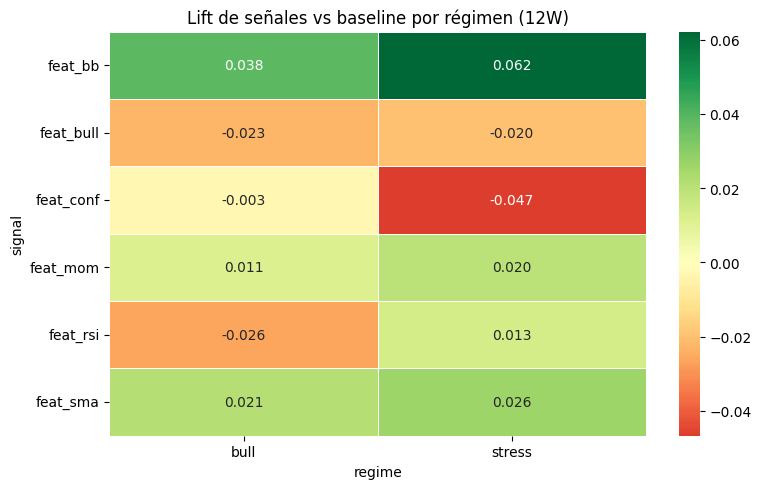

In [20]:
# =========================================================
# BLOQUE 17 — EFICACIA DE SEÑALES POR RÉGIMEN
# =========================================================

df = final_weekly_structure.copy()

if "fwd_ret_4" not in df.columns:
    df["fwd_ret_4"]  = df["Close"].shift(-4)  / df["Close"] - 1
if "fwd_ret_12" not in df.columns:
    df["fwd_ret_12"] = df["Close"].shift(-12) / df["Close"] - 1

SIGNAL_COLS = ["feat_rsi", "feat_bb", "feat_sma", "feat_mom", "feat_bull", "feat_conf"]

# ─── A) Rendimiento por señal × régimen ──────────────────
rows = []
for signal in SIGNAL_COLS:
    for regime in ["bull", "stress", "neutral"]:
        subset = df[(df["meta_state"] == regime) & (df[signal] == 1)]
        if len(subset) < 10:
            continue
        rows.append({
            "signal":       signal,
            "regime":       regime,
            "count":        len(subset),
            "avg_ret_4w":   subset["fwd_ret_4"].mean(),
            "avg_ret_12w":  subset["fwd_ret_12"].mean(),
            "hit_rate_4w":  (subset["fwd_ret_4"]  > 0).mean(),
            "hit_rate_12w": (subset["fwd_ret_12"] > 0).mean(),
        })

signal_table = pd.DataFrame(rows)
print("📊 RENDIMIENTO DE SEÑALES POR RÉGIMEN")
display(signal_table.round(4))

# ─── B) Lift vs baseline del régimen ─────────────────────
regime_baseline = df.groupby("meta_state")["fwd_ret_12"].mean()

lift_rows = []
for signal in SIGNAL_COLS:
    for regime in ["bull", "stress"]:
        subset = df[(df["meta_state"] == regime) & (df[signal] == 1)]
        signal_ret = subset["fwd_ret_12"].mean()
        baseline   = regime_baseline[regime]
        lift_rows.append({
            "signal":          signal,
            "regime":          regime,
            "signal_ret_12w":  signal_ret,
            "regime_baseline": baseline,
            "lift":            signal_ret - baseline,
            "count":           len(subset),
        })

lift_table = pd.DataFrame(lift_rows)
print("\n📊 LIFT DE SEÑALES VS BASELINE DEL RÉGIMEN")
display(lift_table.round(4))

# ─── Heatmap lift ────────────────────────────────────────
pivot = lift_table.pivot(index="signal", columns="regime", values="lift")
plt.figure(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt=".3f", cmap="RdYlGn", center=0, linewidths=0.5)
plt.title("Lift de señales vs baseline por régimen (12W)")
plt.tight_layout()
plt.show()


### BLOQUE 18 — Combinaciones de features

¿Qué pares y tríos de señales funcionan mejor juntos?
Exploramos exhaustivamente todas las combinaciones de 2 y 3 features,
evaluando el retorno 12W y la hit rate.

Nota: un resultado es **robusto** si tiene buen retorno Y buena hit rate Y
suficientes observaciones (n ≥ 20).


In [21]:
# =========================================================
# BLOQUE 18 — COMBINACIONES DE 2 Y 3 FEATURES
# =========================================================

df = final_weekly_structure.copy()
if "fwd_ret_12" not in df.columns:
    df["fwd_ret_12"] = df["Close"].shift(-12) / df["Close"] - 1
if "fwd_ret_4" not in df.columns:
    df["fwd_ret_4"] = df["Close"].shift(-4) / df["Close"] - 1

SIGNAL_COLS = ["feat_rsi", "feat_bb", "feat_sma", "feat_mom", "feat_bull", "feat_conf"]

# ─── Combinaciones de 2 ──────────────────────────────────
rows2 = []
for f1, f2 in combinations(SIGNAL_COLS, 2):
    subset = df[(df[f1] == 1) & (df[f2] == 1)]
    if len(subset) < 10:
        continue
    rows2.append({
        "combo":       f"{f1}+{f2}",
        "count":       len(subset),
        "ret_4w":      subset["fwd_ret_4"].mean(),
        "ret_12w":     subset["fwd_ret_12"].mean(),
        "hit_rate_12": (subset["fwd_ret_12"] > 0).mean(),
    })

combo2 = pd.DataFrame(rows2).sort_values("ret_12w", ascending=False)
print("📊 MEJORES COMBINACIONES DE 2 FEATURES (12W)")
display(combo2.head(10).round(4))

# ─── Combinaciones de 3 por régimen ──────────────────────
rows3r = []
for regime in ["bull", "stress"]:
    df_reg = df[df["meta_state"] == regime]
    for combo in combinations(SIGNAL_COLS, 3):
        mask = np.ones(len(df_reg), dtype=bool)
        for feat in combo:
            mask &= (df_reg[feat] == 1)
        subset = df_reg[mask]
        if len(subset) < 10:
            continue
        rows3r.append({
            "regime":     regime,
            "combo":      "+".join(combo),
            "count":      len(subset),
            "ret_12w":    subset["fwd_ret_12"].mean(),
            "hit_rate":   (subset["fwd_ret_12"] > 0).mean(),
        })

combo3r = (
    pd.DataFrame(rows3r)
    .sort_values(["regime", "ret_12w"], ascending=[True, False])
)
print("\n📊 MEJORES COMBINACIONES DE 3 FEATURES POR RÉGIMEN (12W)")
display(combo3r.groupby("regime").head(5).round(4))

# ─── feat_bull dentro de stress (análisis especial) ──────
stress = df[df["meta_state"] == "stress"].copy()
bull_in_stress = (
    stress.groupby("feat_bull")
    .agg(
        count        = ("fwd_ret_12", "size"),
        avg_ret_4w   = ("fwd_ret_4",  "mean"),
        avg_ret_12w  = ("fwd_ret_12", "mean"),
        hit_rate_12w = ("fwd_ret_12", lambda x: (x > 0).mean()),
    )
)
print("\n📊 feat_bull DENTRO DEL RÉGIMEN STRESS")
print("(feat_bull=1 significa: 'el modelo predice bull aunque estemos en stress')")
display(bull_in_stress.round(4))


📊 MEJORES COMBINACIONES DE 2 FEATURES (12W)


,combo,count,ret_4w,ret_12w,hit_rate_12
5,feat_bb+feat_mom,26,0.0490,0.1088,0.6923
4,feat_bb+feat_sma,26,0.0496,0.1016,0.6923
2,feat_rsi+feat_mom,16,0.0339,0.0628,0.6875
0,feat_rsi+feat_bb,17,0.0049,0.0591,0.5294
1,feat_rsi+feat_sma,21,0.0275,0.0563,0.7619
6,feat_sma+feat_mom,947,0.0118,0.0340,0.7054
7,feat_sma+feat_bull,46,-0.0006,0.0245,0.6087
9,feat_mom+feat_conf,10,0.0011,0.0068,0.4000
8,feat_mom+feat_bull,50,-0.0133,-0.0141,0.4600
3,feat_rsi+feat_bull,20,-0.0405,-0.0182,0.4000



📊 MEJORES COMBINACIONES DE 3 FEATURES POR RÉGIMEN (12W)


,regime,combo,count,ret_12w,hit_rate
0,bull,feat_sma+feat_mom+feat_bull,11,0.0913,0.9091



📊 feat_bull DENTRO DEL RÉGIMEN STRESS
(feat_bull=1 significa: 'el modelo predice bull aunque estemos en stress')


,count,avg_ret_4w,avg_ret_12w,hit_rate_12w
feat_bull,,,,
0,212,0.0074,0.0073,0.5472
1,29,-0.0180,-0.0157,0.5172


---
## 💡 Parte 7 — ¿Agrega Valor el Forecast?
### BLOQUE 19 — Motor de retorno condicional

Comparamos 4 setups incrementales para medir si el forecast agrega valor
**por encima** de las señales clásicas:

1. `SMA_ONLY`: solo tendencia
2. `MOM_ONLY`: solo momentum
3. `SMA+MOM`: combinación clásica
4. `SMA+MOM+BULL`: más el filtro del forecast

Si el paso de 3→4 mejora el retorno Y la hit rate, el forecast agrega valor.


📊 RETORNOS CONDICIONALES POR SETUP


,setup,count,coverage,ret_1w,ret_4w,ret_12w,hit_1w,hit_4w,hit_12w
0,SMA_ONLY,988,0.7445,0.0031,0.0125,0.0376,0.5769,0.6599,0.7287
1,MOM_ONLY,1034,0.7792,0.0030,0.0114,0.0348,0.5725,0.6499,0.7147
2,SMA+MOM,935,0.7046,0.0028,0.0109,0.0340,0.5722,0.6460,0.7144
3,SMA+MOM+BULL,33,0.0249,-0.0025,-0.0213,-0.0093,0.3939,0.3636,0.4545


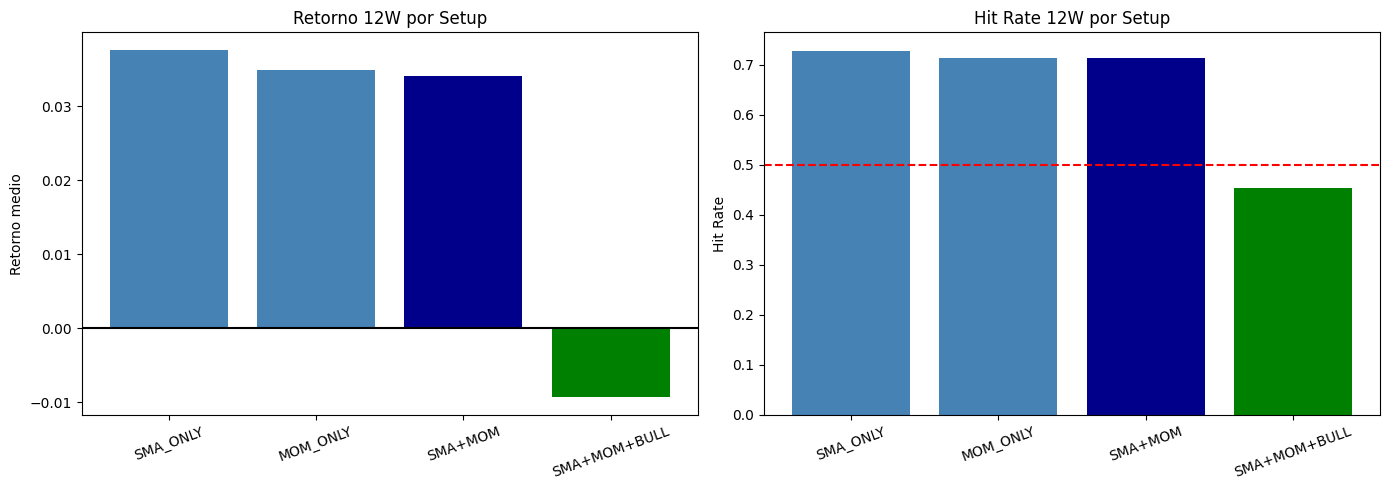

In [22]:
# =========================================================
# BLOQUE 19 — MOTOR DE RETORNO CONDICIONAL
# =========================================================

df = final_weekly_structure.copy()
for h in [1, 4, 12]:
    if f"fwd_ret_{h}" not in df.columns:
        df[f"fwd_ret_{h}"] = df["Close"].shift(-h) / df["Close"] - 1

conditions = {
    "SMA_ONLY":     (df["feat_sma"] == 1),
    "MOM_ONLY":     (df["feat_mom"] == 1),
    "SMA+MOM":      ((df["feat_sma"] == 1) & (df["feat_mom"] == 1)),
    "SMA+MOM+BULL": ((df["feat_sma"] == 1) & (df["feat_mom"] == 1) & (df["feat_bull"] == 1)),
}

rows = []
for name, mask in conditions.items():
    sub = df[mask].dropna(subset=["fwd_ret_1","fwd_ret_4","fwd_ret_12"])
    rows.append({
        "setup":      name,
        "count":      len(sub),
        "coverage":   len(sub) / len(df),
        "ret_1w":     sub["fwd_ret_1"].mean(),
        "ret_4w":     sub["fwd_ret_4"].mean(),
        "ret_12w":    sub["fwd_ret_12"].mean(),
        "hit_1w":    (sub["fwd_ret_1"] > 0).mean(),
        "hit_4w":    (sub["fwd_ret_4"] > 0).mean(),
        "hit_12w":   (sub["fwd_ret_12"] > 0).mean(),
    })

cond_df = pd.DataFrame(rows)
print("📊 RETORNOS CONDICIONALES POR SETUP")
display(cond_df.round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(cond_df["setup"], cond_df["ret_12w"], color=["steelblue","steelblue","darkblue","green"])
axes[0].axhline(0, color="black")
axes[0].set_title("Retorno 12W por Setup")
axes[0].set_ylabel("Retorno medio")
axes[0].tick_params(axis='x', rotation=20)

axes[1].bar(cond_df["setup"], cond_df["hit_12w"], color=["steelblue","steelblue","darkblue","green"])
axes[1].axhline(0.5, color="red", linestyle="--")
axes[1].set_title("Hit Rate 12W por Setup")
axes[1].set_ylabel("Hit Rate")
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()


### BLOQUE 20 — Análisis de confianza y decaimiento de información

- **Deciles de confianza:** ¿Retornos más altos cuando la probabilidad es más extrema?
- **Information decay:** ¿Cuánto dura la señal predictiva? (1W, 4W, 12W, 24W)


📊 RETORNOS POR DECIL DE CONFIANZA (pred_prob_bull)


,count,avg_prob,ret_4w,ret_12w,hit_4w,hit_12w
confidence_decile,,,,,,
1,41,0.0826,0.0046,0.0145,0.5366,0.5366
2,41,0.1375,0.0326,0.1105,0.5610,0.6341
3,41,0.1793,0.0271,0.0942,0.6341,0.6829
4,41,0.2288,0.0589,0.0942,0.7073,0.6098
5,41,0.2816,0.0348,0.1888,0.5366,0.6341
6,41,0.3738,-0.0014,0.1055,0.5122,0.5122
7,41,0.4819,0.0874,0.2213,0.5854,0.6829
8,41,0.6164,0.0842,0.1357,0.5854,0.6341
9,41,0.7517,0.0104,0.0629,0.3659,0.5610



📊 DECAIMIENTO DE INFORMACIÓN — Retorno por horizonte


,bucket,count,ret_1w,ret_2w,ret_4w,ret_8w,ret_12w,ret_24w
0,"(0.0, 0.2]",121,0.0095,0.0167,0.0221,0.0349,0.0744,0.1537
1,"(0.2, 0.4]",114,0.0022,0.0153,0.0363,0.0784,0.1305,0.2810
2,"(0.4, 0.6]",67,0.0096,0.0184,0.0554,0.1584,0.1727,0.3230
3,"(0.6, 0.8]",63,0.0244,0.0256,0.0404,0.0612,0.0835,0.1641
4,"(0.8, 1.0]",45,-0.0040,0.0054,0.0214,0.0284,0.0847,0.1809


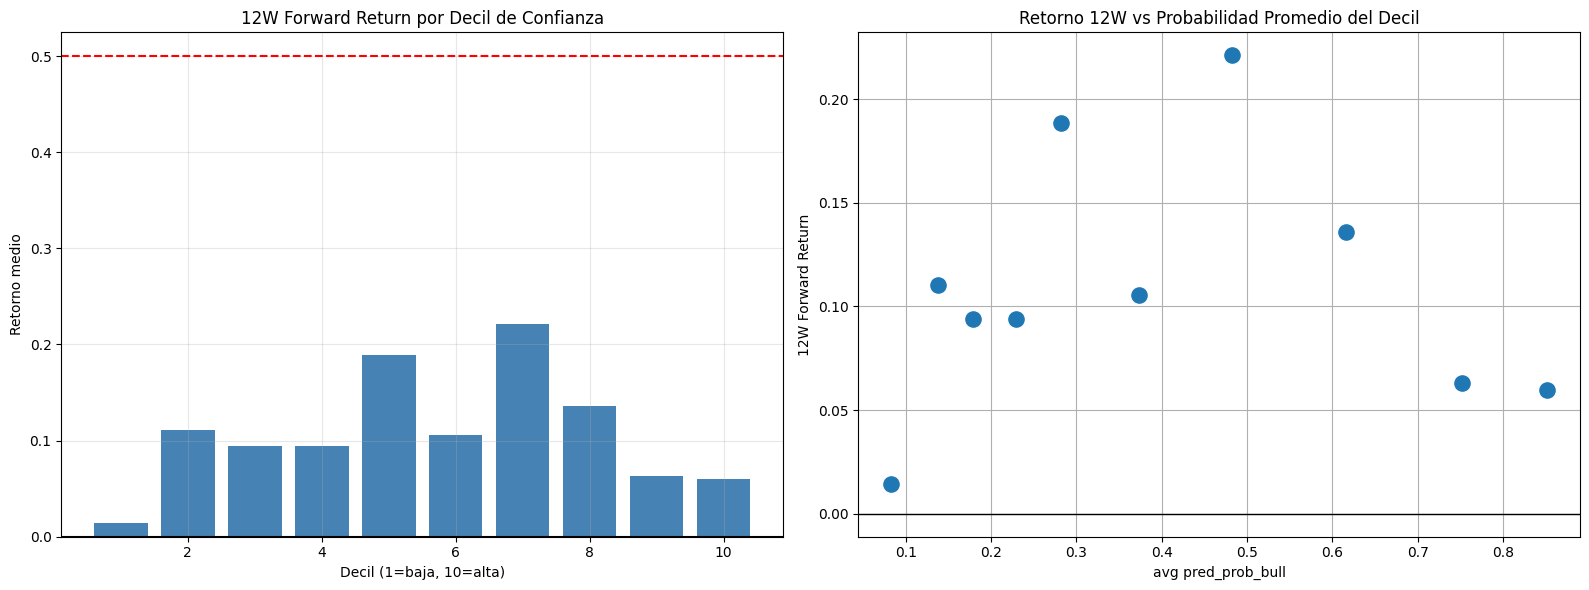

In [23]:
# =========================================================
# BLOQUE 20 — CONFIANZA Y DECAIMIENTO DE INFORMACIÓN
# =========================================================

df = final_weekly_structure.dropna(subset=["pred_prob_bull"]).copy()
horizons = [1, 2, 4, 8, 12, 24]
for h in horizons:
    df[f"ret_{h}w"] = df["Close"].shift(-h) / df["Close"] - 1

# ─── A) Deciles de pred_prob_bull ────────────────────────
df["confidence_decile"] = pd.qcut(
    df["pred_prob_bull"], q=10, labels=False, duplicates="drop"
) + 1

conf_summary = (
    df.groupby("confidence_decile")
    .agg(
        count    = ("pred_prob_bull",  "size"),
        avg_prob = ("pred_prob_bull",  "mean"),
        ret_4w   = ("ret_4w",          "mean"),
        ret_12w  = ("ret_12w",         "mean"),
        hit_4w   = ("ret_4w",  lambda x: (x > 0).mean()),
        hit_12w  = ("ret_12w", lambda x: (x > 0).mean()),
    )
)

print("📊 RETORNOS POR DECIL DE CONFIANZA (pred_prob_bull)")
display(conf_summary.round(4))

# ─── B) Decaimiento de información (information decay) ───
df["forecast_bucket"] = pd.cut(
    df["pred_prob_bull"], bins=np.arange(0, 1.01, 0.2)
)

rows_decay = []
for bucket, grp in df.groupby("forecast_bucket", observed=False):
    row = {"bucket": str(bucket), "count": len(grp)}
    for h in horizons:
        row[f"ret_{h}w"] = grp[f"ret_{h}w"].mean()
    rows_decay.append(row)

decay_table = pd.DataFrame(rows_decay)
print("\n📊 DECAIMIENTO DE INFORMACIÓN — Retorno por horizonte")
display(decay_table.round(4))

# ─── Gráfico decay ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Deciles vs retorno 12W
axes[0].bar(conf_summary.index, conf_summary["ret_12w"], color="steelblue")
axes[0].axhline(0, color="black")
axes[0].axhline(0.5, color="red", linestyle="--")
axes[0].set_title("12W Forward Return por Decil de Confianza")
axes[0].set_xlabel("Decil (1=baja, 10=alta)")
axes[0].set_ylabel("Retorno medio")
axes[0].grid(alpha=0.3)

# Scatter retorno vs confianza promedio
axes[1].scatter(conf_summary["avg_prob"], conf_summary["ret_12w"], s=120, zorder=5)
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_title("Retorno 12W vs Probabilidad Promedio del Decil")
axes[1].set_xlabel("avg pred_prob_bull")
axes[1].set_ylabel("12W Forward Return")
axes[1].grid(True)

plt.tight_layout()
plt.show()


### BLOQUE 21 — Contribución de cada feature al retorno

Para cada feature binario (activo = 1 vs inactivo = 0), medimos:
- **Delta de retorno:** cuánto mejora el retorno 12W cuando la señal está activa.
- **Delta de hit rate:** cuánto mejora la probabilidad de ganar.
- **Delta de drawdown:** cuánto cambia el drawdown máximo esperado.

Un delta positivo en retorno con delta negativo en drawdown es la combinación ideal.


📊 CONTRIBUCIÓN MARGINAL: delta(activo - inactivo)


,feature,ret_delta,hit_delta,dd_delta
1,feat_bb,0.0486,-0.0431,-0.0114
2,feat_sma,0.0298,0.1538,0.0555
3,feat_mom,0.0217,0.1133,0.0556
0,feat_rsi,-0.0066,-0.1046,-0.0473
4,feat_bull,-0.0323,-0.1586,-0.0641
5,feat_conf,-0.0651,-0.3278,-0.0387



📊 RANKING DE FEATURES POR CORRELACIÓN (12W)


,feature,corr_12w,abs_corr
2,feat_sma,0.1263,0.1263
5,feat_conf,-0.1028,0.1028
14,atr_pct,-0.1016,0.1016
12,atr_pct,-0.1016,0.1016
4,feat_bull,-0.0962,0.0962
11,drawdown,0.0897,0.0897
3,feat_mom,0.0871,0.0871
10,price_vs_sma_52,0.0851,0.0851
8,mom_26,0.0849,0.0849
1,feat_bb,0.0788,0.0788


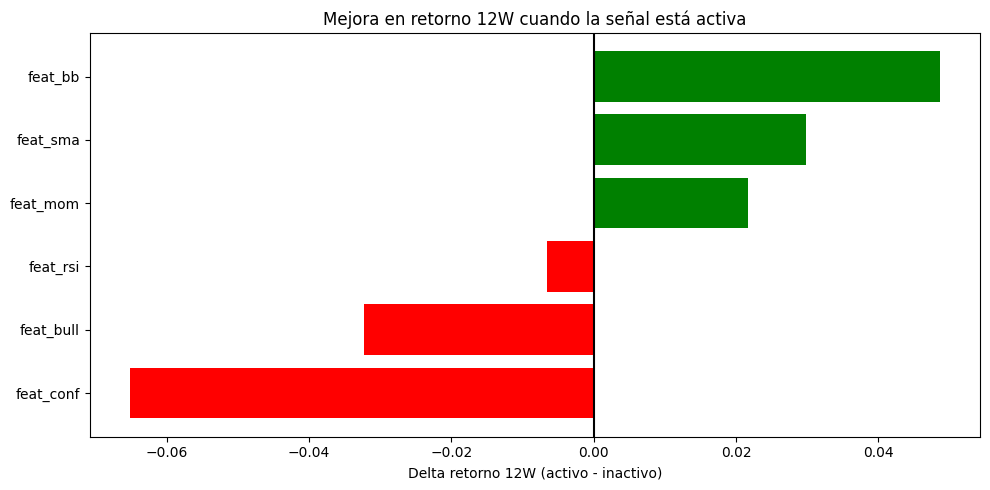

In [24]:
# =========================================================
# BLOQUE 21 — CONTRIBUCIÓN MARGINAL DE CADA FEATURE
# =========================================================

df = final_weekly_structure.copy()
if "fwd_ret_12" not in df.columns:
    df["fwd_ret_12"] = df["Close"].shift(-12) / df["Close"] - 1

# Calcular fwd_dd_12 si no existe
if "fwd_dd_12" not in df.columns:
    future_min = df["Close"].shift(-1).rolling(12).min()
    df["fwd_dd_12"] = future_min / df["Close"] - 1

SIGNAL_COLS = ["feat_rsi", "feat_bb", "feat_sma", "feat_mom", "feat_bull", "feat_conf"]

rows = []
for feature in SIGNAL_COLS:
    for state in [0, 1]:
        subset = df[df[feature] == state].dropna(subset=["fwd_ret_12", "fwd_dd_12"])
        if len(subset) < 20:
            continue
        rows.append({
            "feature": feature,
            "active":  state,
            "count":   len(subset),
            "ret_12w": subset["fwd_ret_12"].mean(),
            "hit_12w": (subset["fwd_ret_12"] > 0).mean(),
            "dd_12w":  subset["fwd_dd_12"].mean(),
        })

feature_df = pd.DataFrame(rows)

# ─── Tabla delta (activo - inactivo) ─────────────────────
delta_rows = []
for feature in feature_df["feature"].unique():
    off = feature_df[(feature_df["feature"]==feature) & (feature_df["active"]==0)]
    on  = feature_df[(feature_df["feature"]==feature) & (feature_df["active"]==1)]
    if len(off)==0 or len(on)==0:
        continue
    delta_rows.append({
        "feature":    feature,
        "ret_delta":  on.iloc[0]["ret_12w"] - off.iloc[0]["ret_12w"],
        "hit_delta":  on.iloc[0]["hit_12w"] - off.iloc[0]["hit_12w"],
        "dd_delta":   on.iloc[0]["dd_12w"]  - off.iloc[0]["dd_12w"],
    })

delta_df = pd.DataFrame(delta_rows).sort_values("ret_delta", ascending=False)
print("📊 CONTRIBUCIÓN MARGINAL: delta(activo - inactivo)")
display(delta_df.round(4))

# ─── Ranking de features por correlación con 12W ─────────
corr_rows = []
for feat in SIGNAL_COLS + ["mom_4", "mom_13", "mom_26", "mom_52",
                            "price_vs_sma_52", "drawdown", "atr_pct",
                            "pred_prob_bull", "trade_score"
                            if "trade_score" in df.columns else "atr_pct"]:
    if feat not in df.columns:
        continue
    tmp = df[[feat, "fwd_ret_12"]].dropna()
    c   = tmp[feat].corr(tmp["fwd_ret_12"])
    corr_rows.append({"feature": feat, "corr_12w": round(c, 4), "abs_corr": round(abs(c), 4)})

corr_ranking = pd.DataFrame(corr_rows).sort_values("abs_corr", ascending=False)
print("\n📊 RANKING DE FEATURES POR CORRELACIÓN (12W)")
display(corr_ranking.head(12))

# ─── Gráfico ──────────────────────────────────────────────
plot_df = delta_df.sort_values("ret_delta")
plt.figure(figsize=(10, 5))
colors = ["green" if v > 0 else "red" for v in plot_df["ret_delta"]]
plt.barh(plot_df["feature"], plot_df["ret_delta"], color=colors)
plt.axvline(0, color="black")
plt.title("Mejora en retorno 12W cuando la señal está activa")
plt.xlabel("Delta retorno 12W (activo - inactivo)")
plt.tight_layout()
plt.show()


---
## 🏆 Parte 8 — Motor de Score
### BLOQUE 22 — Construcción del trade score

Combinamos todas las señales en un **score ponderado** que resume la calidad
de la semana para entrar:

```
trade_score = 3×feat_bull + 2×feat_sma + 2×feat_mom + 1×feat_rsi + 1×feat_bb
```

Ponderaciones justificadas:
- `feat_bull` (×3): señal ML con información prospectiva — mayor peso.
- `feat_sma` y `feat_mom` (×2): señales de tendencia probadas históricamente.
- `feat_rsi` y `feat_bb` (×1): señales contrarias de menor confianza en tendencia.

El score va de 0 (ninguna señal activa) a 9 (todas activas).


In [25]:
# =========================================================
# BLOQUE 22 — CONSTRUCCIÓN DEL TRADE SCORE
# =========================================================

df = final_weekly_structure.copy()

df["trade_score"] = (
      3 * df["feat_bull"]
    + 2 * df["feat_sma"]
    + 2 * df["feat_mom"]
    + 1 * df["feat_rsi"]
    + 1 * df["feat_bb"]
)

# Exportar al dataset principal
final_weekly_structure["trade_score"] = df["trade_score"]

print("📊 DISTRIBUCIÓN DEL TRADE SCORE")
print(df["trade_score"].describe().round(3))
print(f"\nScores posibles: {sorted(df['trade_score'].dropna().unique().astype(int).tolist())}")


📊 DISTRIBUCIÓN DEL TRADE SCORE
count    1327.000
mean        3.472
std         1.444
min         0.000
25%         4.000
50%         4.000
75%         4.000
max         8.000
Name: trade_score, dtype: float64

Scores posibles: [0, 1, 2, 3, 4, 5, 6, 7, 8]


📊 ANÁLISIS POR SCORE


,score,count,ret_1w,ret_12w,hit_12w,dd_12w
0,0,125,0.0026,-0.0120,0.5040,-0.0950
1,1,25,0.0088,0.0152,0.5200,-0.1003
2,2,116,0.0036,0.0632,0.8017,-0.0276
3,3,62,-0.0113,0.0067,0.6290,-0.1333
4,4,892,0.0024,0.0337,0.7209,-0.0371
5,5,58,0.0115,0.0476,0.6724,-0.0555
6,7,32,-0.0018,-0.0045,0.4688,-0.0663



Correlación Score → Retorno 12W : 0.0793
Correlación Score → Hit Rate   : -0.0166
Correlación Score → Drawdown   : 0.3179


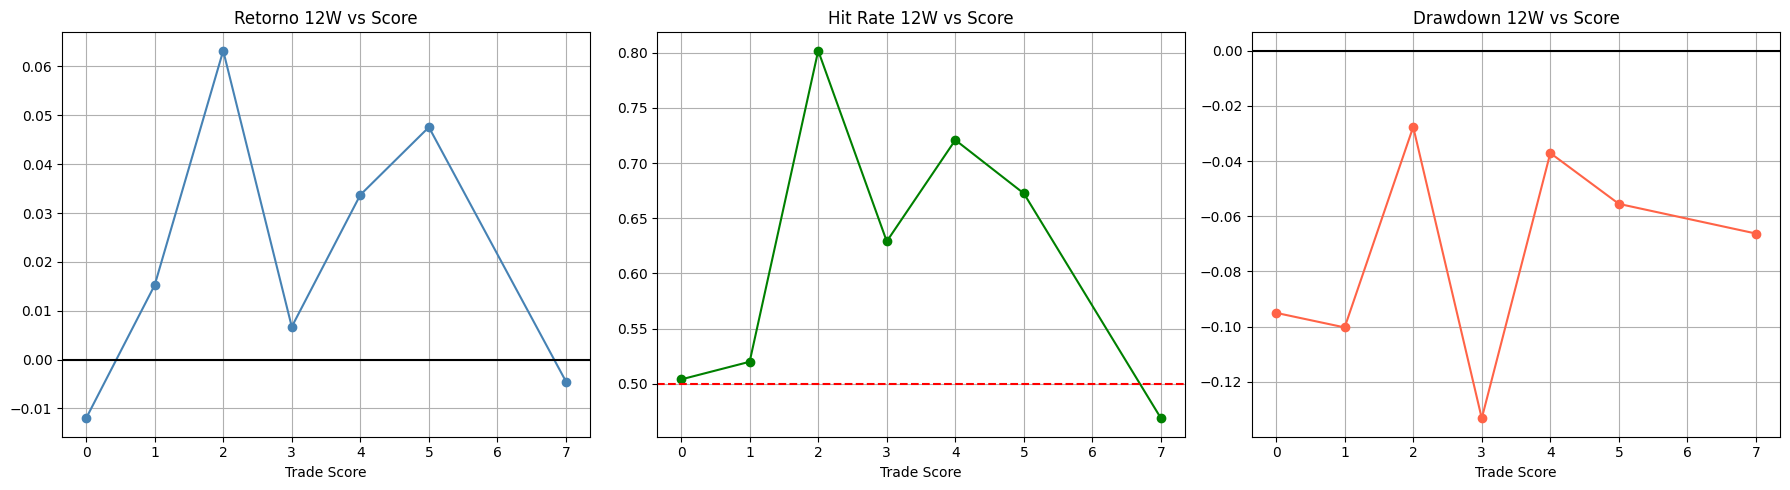

In [26]:
# =========================================================
# BLOQUE 23 — ANÁLISIS DEL SCORE: RETORNO Y HIT RATE
# =========================================================

df = final_weekly_structure.copy()
if "fwd_ret_12" not in df.columns:
    df["fwd_ret_12"] = df["Close"].shift(-12) / df["Close"] - 1
if "fwd_dd_12" not in df.columns:
    future_min = df["Close"].shift(-1).rolling(12).min()
    df["fwd_dd_12"] = future_min / df["Close"] - 1

rows = []
for score in sorted(df["trade_score"].dropna().unique()):
    sub = df[df["trade_score"] == score].dropna(subset=["fwd_ret_12", "fwd_dd_12"])
    if len(sub) < 10:
        continue
    rows.append({
        "score":   score,
        "count":   len(sub),
        "ret_1w":  sub["fwd_ret_1"].mean() if "fwd_ret_1" in sub.columns else np.nan,
        "ret_12w": sub["fwd_ret_12"].mean(),
        "hit_12w": (sub["fwd_ret_12"] > 0).mean(),
        "dd_12w":  sub["fwd_dd_12"].mean(),
    })

score_df = pd.DataFrame(rows)
print("📊 ANÁLISIS POR SCORE")
display(score_df.round(4))

# Correlaciones
print(f"\nCorrelación Score → Retorno 12W : {score_df['score'].corr(score_df['ret_12w']):.4f}")
print(f"Correlación Score → Hit Rate   : {score_df['score'].corr(score_df['hit_12w']):.4f}")
print(f"Correlación Score → Drawdown   : {score_df['score'].corr(score_df['dd_12w']):.4f}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(score_df["score"], score_df["ret_12w"], marker="o", color="steelblue")
axes[0].axhline(0, color="black"); axes[0].set_title("Retorno 12W vs Score")
axes[0].set_xlabel("Trade Score"); axes[0].grid(True)

axes[1].plot(score_df["score"], score_df["hit_12w"], marker="o", color="green")
axes[1].axhline(0.5, color="red", linestyle="--"); axes[1].set_title("Hit Rate 12W vs Score")
axes[1].set_xlabel("Trade Score"); axes[1].grid(True)

axes[2].plot(score_df["score"], score_df["dd_12w"], marker="o", color="tomato")
axes[2].axhline(0, color="black"); axes[2].set_title("Drawdown 12W vs Score")
axes[2].set_xlabel("Trade Score"); axes[2].grid(True)

plt.tight_layout()
plt.show()


### BLOQUE 24 — Threshold research: ¿cuál es el mínimo score para entrar?

En lugar de un umbral fijo, exploramos todos los posibles umbrales mínimos.
Para cada umbral T, tomamos todas las semanas con `trade_score ≥ T` y calculamos:
- Retorno medio 12W
- Hit rate 12W
- Drawdown medio 12W
- Eficiencia = retorno / |drawdown| (quiero maximizar esto)


📊 THRESHOLD RESEARCH


,threshold,count,exposure,ret_12w,hit_12w,dd_12w,efficiency
0,0,1315,0.9910,0.0302,0.6905,-0.0490,0.6158
1,1,1190,0.8968,0.0346,0.7101,-0.0442,0.7834
2,2,1165,0.8779,0.0350,0.7142,-0.0430,0.8150
3,3,1049,0.7905,0.0319,0.7045,-0.0447,0.7143
4,4,987,0.7438,0.0335,0.7092,-0.0391,0.8563
5,5,95,0.0716,0.0316,0.6000,-0.0582,0.5427
6,6,37,0.0279,0.0065,0.4865,-0.0625,0.1048
7,7,33,0.0249,-0.0093,0.4545,-0.0692,-0.1347



🏆 MEJOR THRESHOLD: score ≥ 4
   Retorno 12W  : 0.0335
   Hit Rate 12W : 0.7092
   Eficiencia   : 0.8563
   Cobertura    : 74.4%


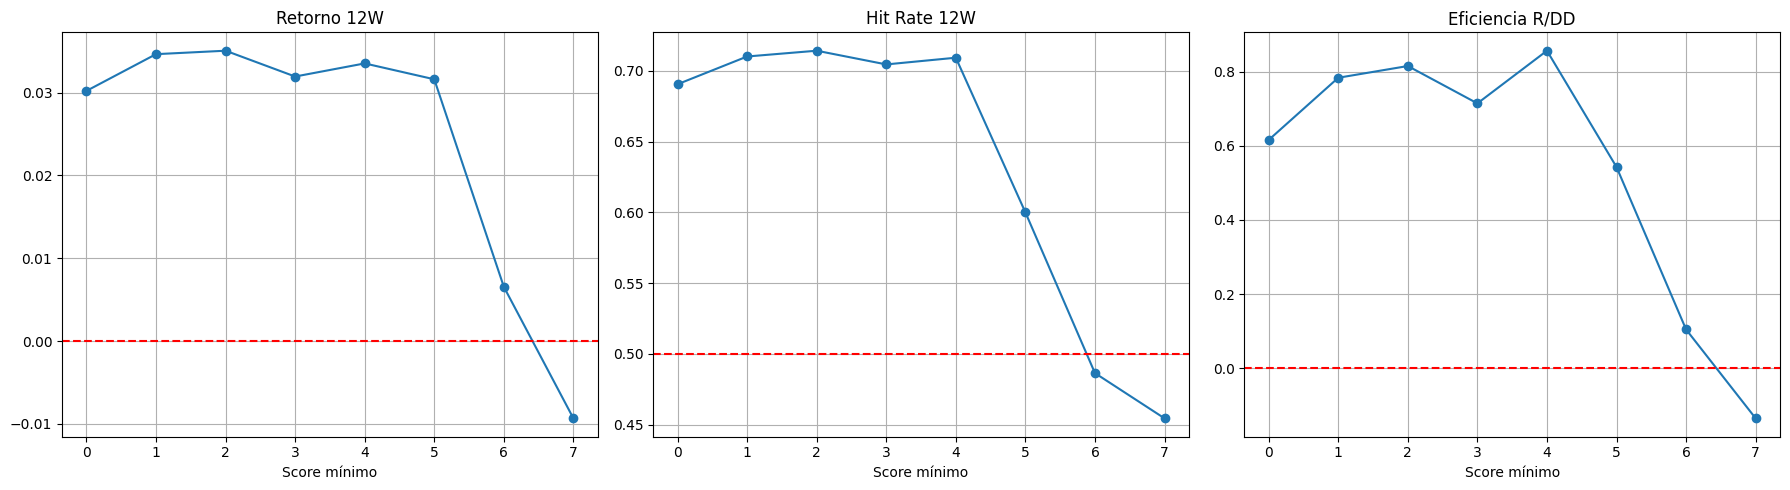

In [27]:
# =========================================================
# BLOQUE 24 — THRESHOLD RESEARCH
# =========================================================

df = final_weekly_structure.copy()
if "fwd_ret_12" not in df.columns:
    df["fwd_ret_12"] = df["Close"].shift(-12) / df["Close"] - 1
if "fwd_dd_12" not in df.columns:
    future_min = df["Close"].shift(-1).rolling(12).min()
    df["fwd_dd_12"] = future_min / df["Close"] - 1

results = []
for threshold in sorted(df["trade_score"].dropna().unique()):
    subset = df[df["trade_score"] >= threshold].dropna(subset=["fwd_ret_12", "fwd_dd_12"])
    if len(subset) < 20:
        continue
    results.append({
        "threshold": threshold,
        "count":     len(subset),
        "exposure":  len(subset) / len(df),
        "ret_12w":   subset["fwd_ret_12"].mean(),
        "hit_12w":  (subset["fwd_ret_12"] > 0).mean(),
        "dd_12w":    subset["fwd_dd_12"].mean(),
    })

thr_df = pd.DataFrame(results)
thr_df["efficiency"] = thr_df["ret_12w"] / thr_df["dd_12w"].abs()

print("📊 THRESHOLD RESEARCH")
display(thr_df.round(4))

best = thr_df.sort_values("efficiency", ascending=False).iloc[0]
print(f"\n🏆 MEJOR THRESHOLD: score ≥ {int(best['threshold'])}")
print(f"   Retorno 12W  : {best['ret_12w']:.4f}")
print(f"   Hit Rate 12W : {best['hit_12w']:.4f}")
print(f"   Eficiencia   : {best['efficiency']:.4f}")
print(f"   Cobertura    : {best['exposure']:.1%}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col, title, hline in [
    (axes[0], "ret_12w",    "Retorno 12W",    0),
    (axes[1], "hit_12w",    "Hit Rate 12W",   0.5),
    (axes[2], "efficiency", "Eficiencia R/DD", 0),
]:
    ax.plot(thr_df["threshold"], thr_df[col], marker="o")
    ax.axhline(hline, color="red", linestyle="--")
    ax.set_title(title)
    ax.set_xlabel("Score mínimo")
    ax.grid(True)

plt.tight_layout()
plt.show()


### BLOQUE 25 — Sistema de signatures

Una **signature** es la combinación exacta de 6 señales binarias para una semana dada.
Con 6 features binarios, hay 2⁶ = 64 posibles combinaciones.

Cada signature tiene un perfil de retorno y riesgo único.
Buscamos las signatures con:
- Buen retorno 12W promedio
- Alta hit rate
- Suficientes observaciones (n ≥ 20) para ser estadísticamente relevantes.

La **quality score** combina las tres dimensiones:
```
quality = avg_ret_12 × log(count) × hit_rate_12
```


📊 MASTER SIGNATURE TABLE (n ≥ 20, ordenado por quality_score)


,signature,count,avg_ret_4,avg_ret_12,hit_rate_4,hit_rate_12,avg_score,pct_bull,quality_score
7,001000,31,0.0419,0.1023,0.9677,0.9677,2.0,0.2581,0.3430
4,000100,76,0.0176,0.0537,0.6974,0.7632,2.0,0.2500,0.1779
10,001100,876,0.0123,0.0343,0.6632,0.7192,4.0,0.0479,0.1674
17,100000,23,0.0073,0.0113,0.6522,0.5217,1.0,0.4783,0.0188
2,000010,52,-0.0434,-0.0019,0.3654,0.5769,3.0,0.4808,-0.0044
12,001110,32,-0.0232,-0.0045,0.3438,0.4688,7.0,0.3438,-0.0074
0,000000,103,0.0123,-0.0067,0.5825,0.5340,0.0,0.1650,-0.0166
1,000001,22,0.0066,-0.0369,0.5000,0.3636,0.0,0.0000,-0.0421


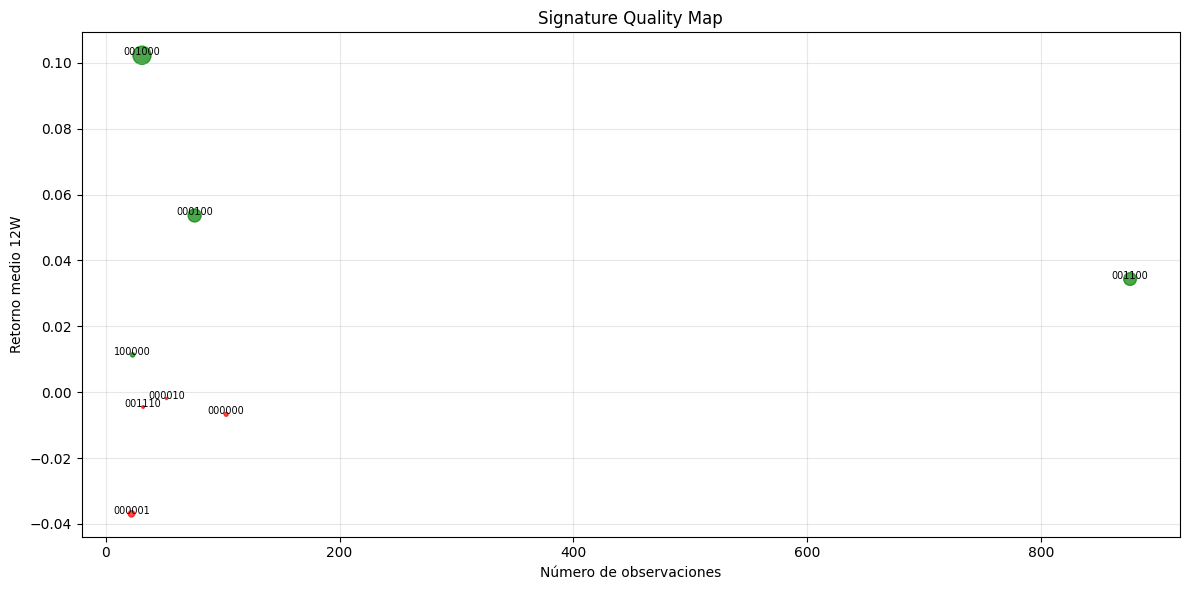

In [28]:
# =========================================================
# BLOQUE 25 — SISTEMA DE SIGNATURES
# =========================================================

df = final_weekly_structure.copy()
if "fwd_ret_12" not in df.columns:
    df["fwd_ret_12"] = df["Close"].shift(-12) / df["Close"] - 1
if "fwd_ret_4" not in df.columns:
    df["fwd_ret_4"] = df["Close"].shift(-4) / df["Close"] - 1

SIGNAL_COLS = ["feat_rsi", "feat_bb", "feat_sma", "feat_mom", "feat_bull", "feat_conf"]

df["signature"] = (
    df[SIGNAL_COLS]
    .astype(int)
    .astype(str)
    .agg("".join, axis=1)
)

# Exportar signature al dataset principal
final_weekly_structure["signature"] = df["signature"]

# ─── Master signature table ──────────────────────────────
sig_master = (
    df.groupby("signature")
    .agg(
        count       = ("signature",   "size"),
        avg_ret_4   = ("fwd_ret_4",   "mean"),
        avg_ret_12  = ("fwd_ret_12",  "mean"),
        hit_rate_4  = ("fwd_ret_4",  lambda x: (x > 0).mean()),
        hit_rate_12 = ("fwd_ret_12", lambda x: (x > 0).mean()),
        avg_score   = ("trade_score", "mean"),
        pct_bull    = ("meta_state",  lambda x: (x == "bull").mean()),
    )
    .reset_index()
)

sig_master["quality_score"] = (
    sig_master["avg_ret_12"]
    * np.log1p(sig_master["count"])
    * sig_master["hit_rate_12"]
)

robust_sigs = (
    sig_master[sig_master["count"] >= 20]
    .sort_values("quality_score", ascending=False)
)

print("📊 MASTER SIGNATURE TABLE (n ≥ 20, ordenado por quality_score)")
display(robust_sigs.round(4))

# ─── Scatter quality map ─────────────────────────────────
plt.figure(figsize=(12, 6))
sizes = np.abs(robust_sigs["quality_score"]) * 500
colors = ["green" if v > 0 else "red" for v in robust_sigs["quality_score"]]
plt.scatter(robust_sigs["count"], robust_sigs["avg_ret_12"], s=sizes, c=colors, alpha=0.7)
for _, row in robust_sigs.iterrows():
    plt.annotate(
        row["signature"],
        (row["count"], row["avg_ret_12"]),
        fontsize=7, ha="center"
    )
plt.xlabel("Número de observaciones"); plt.ylabel("Retorno medio 12W")
plt.title("Signature Quality Map")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### BLOQUE 26 — Robustez por decade y estrategia candidata

¿Las mejores signatures funcionan en todos los períodos o solo en algunos?
Dividimos en 3 décadas y verificamos consistencia.

También identificamos la **estrategia candidata** más prometedora basada en
los hallazgos previos: `meta_state == stress` + `feat_sma == 1` + `feat_mom == 1`.


In [29]:
# =========================================================
# BLOQUE 26 — ROBUSTEZ POR DÉCADA Y ESTRATEGIA CANDIDATA
# =========================================================

df = final_weekly_structure.copy()
if "fwd_ret_12" not in df.columns:
    df["fwd_ret_12"] = df["Close"].shift(-12) / df["Close"] - 1

SIGNAL_COLS = ["feat_rsi", "feat_bb", "feat_sma", "feat_mom", "feat_bull", "feat_conf"]
df["signature"] = (
    df[SIGNAL_COLS].astype(int).astype(str).agg("".join, axis=1)
)
df["year"]   = df.index.year
df["period"] = pd.cut(
    df["year"], bins=[2000, 2010, 2020, 2030],
    labels=["2001-2010", "2011-2020", "2021-2030"]
)

# Las 5 signatures más frecuentes / robustas
top_sigs = robust_sigs.head(5)["signature"].tolist()

robustness = (
    df[df["signature"].isin(top_sigs)]
    .groupby(["signature", "period"])
    .agg(
        count    = ("signature", "size"),
        ret_12w  = ("fwd_ret_12", "mean"),
        hit_rate = ("fwd_ret_12", lambda x: (x > 0).mean()),
    )
    .reset_index()
)

print("📊 ROBUSTEZ POR PERÍODO (top 5 signatures)")
display(robustness.round(4))

# ─── Estrategia candidata ─────────────────────────────────
signal = (
    (df["meta_state"] == "stress") &
    (df["feat_sma"] == 1) &
    (df["feat_mom"] == 1)
)
strategy_sub = df[signal].copy()
benchmark    = df.copy()

strat_ret_12  = strategy_sub["fwd_ret_12"].mean()
bench_ret_12  = benchmark["fwd_ret_12"].mean()
strat_hit_12  = (strategy_sub["fwd_ret_12"] > 0).mean()
bench_hit_12  = (benchmark["fwd_ret_12"] > 0).mean()

comparison = pd.DataFrame({
    "setup":    ["stress+sma+mom", "mercado completo"],
    "count":    [len(strategy_sub), len(benchmark)],
    "coverage": [len(strategy_sub)/len(df), 1.0],
    "ret_12w":  [strat_ret_12, bench_ret_12],
    "hit_12w":  [strat_hit_12, bench_hit_12],
    "lift":     [strat_ret_12 - bench_ret_12, 0],
})

print("\n📊 ESTRATEGIA CANDIDATA vs MERCADO")
display(comparison.round(4))

# Agregar versión con feat_bull
signal_plus = signal & (df["feat_bull"] == 1)
strategy_plus = df[signal_plus].copy()
comparison2 = pd.DataFrame({
    "group":    ["stress+sma+mom", "stress+sma+mom+bull"],
    "count":    [len(strategy_sub), len(strategy_plus)],
    "ret_12w":  [strat_ret_12, strategy_plus["fwd_ret_12"].mean()],
    "hit_12w":  [strat_hit_12, (strategy_plus["fwd_ret_12"] > 0).mean()],
})
print("\n📊 EFECTO DE AÑADIR feat_bull A LA ESTRATEGIA CANDIDATA")
display(comparison2.round(4))


📊 ROBUSTEZ POR PERÍODO (top 5 signatures)


,signature,period,count,ret_12w,hit_rate
0,000010,2001-2010,40,-0.0214,0.5250
1,000010,2021-2030,12,0.0629,0.7500
2,000100,2001-2010,39,0.0427,0.6410
3,000100,2011-2020,36,0.0705,0.9167
4,000100,2021-2030,1,-0.1256,0.0000
5,001000,2001-2010,24,0.0921,0.9583
6,001000,2011-2020,1,0.0412,1.0000
7,001000,2021-2030,6,0.1531,1.0000
8,001100,2001-2010,223,0.0189,0.6368
9,001100,2011-2020,444,0.0418,0.7748



📊 ESTRATEGIA CANDIDATA vs MERCADO


,setup,count,coverage,ret_12w,hit_12w,lift
0,stress+sma+mom,101,0.0761,0.0234,0.6040,-0.0068
1,mercado completo,1327,1.0000,0.0302,0.6843,0.0000



📊 EFECTO DE AÑADIR feat_bull A LA ESTRATEGIA CANDIDATA


,group,count,ret_12w,hit_12w
0,stress+sma+mom,101,0.0234,0.604
1,stress+sma+mom+bull,5,-0.1123,0.200


---
## 📈 Parte 9 — Backtesting
### Contexto: ¿por qué necesitamos múltiples versiones?

El backtest más simple (V0) usa solo tendencia + momentum en modo binario.
Cada versión posterior intenta incorporar el forecast de regímenes de distinta manera:

| Versión | Señal de entrada | Tamaño de posición | Insight |
|---------|-------------------|--------------------|---------|
| **V0** | SMA + MOM | 100% o 0% | Baseline clásico |
| **V1** | SMA + MOM + BULL>0.5 | 100% o 0% | Forecast como filtro duro |
| **V2** | SMA + MOM | pred_prob_bull (continuo) | Forecast como sizing |
| **V3** | SMA + MOM + BULL>T | 100% o 0% | Umbral suave variable |
| **V4** | Trade Strength Score | Normalizado continuo | Score completo como sizing |

**Convención:** posición del período t+1 se decide en el cierre de t (sin lookahead).

### BLOQUE 27 — Backtest V0: SMA + MOM (baseline)



📊 BACKTEST V0 — SMA + MOM (Binario)
─────────────────────────────────────────────
  Buy & Hold CAGR    : 11.35%
  Strategy   CAGR    : 10.65%
  Buy & Hold Max DD  : -69.31%
  Strategy   Max DD  : -27.25%
  Buy & Hold Sharpe  : 0.59
  Strategy   Sharpe  : 0.74
  Exposición         : 71.4%


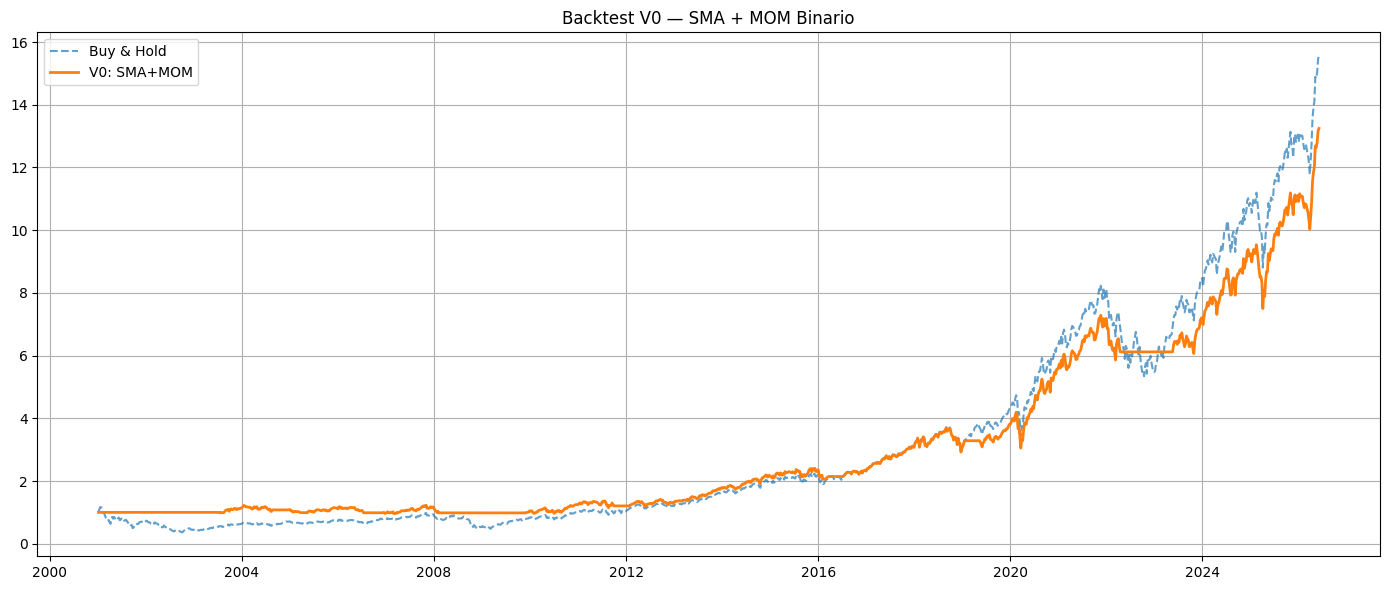

In [30]:
# =========================================================
# BLOQUE 27 — BACKTEST V0: SMA + MOM (Baseline)
# =========================================================

df = final_weekly_structure.copy()
df["asset_return"] = df["Close"].pct_change()

# Señales (ya están en final_weekly_structure)
trend_on = (df["feat_sma"] == 1) & (df["feat_mom"] == 1)
df["position"] = np.where(trend_on, 1, 0)

df["strategy_return"] = df["position"].shift(1).fillna(0) * df["asset_return"]
df["buy_hold"]  = (1 + df["asset_return"].fillna(0)).cumprod()
df["strategy"]  = (1 + df["strategy_return"].fillna(0)).cumprod()

print("\n📊 BACKTEST V0 — SMA + MOM (Binario)")
print("─" * 45)
print(f"  Buy & Hold CAGR    : {cagr(df['buy_hold']):.2%}")
print(f"  Strategy   CAGR    : {cagr(df['strategy']):.2%}")
print(f"  Buy & Hold Max DD  : {max_dd(df['buy_hold']):.2%}")
print(f"  Strategy   Max DD  : {max_dd(df['strategy']):.2%}")
print(f"  Buy & Hold Sharpe  : {sharpe(df['asset_return']):.2f}")
print(f"  Strategy   Sharpe  : {sharpe(df['strategy_return']):.2f}")
print(f"  Exposición         : {df['position'].mean():.1%}")

plt.figure(figsize=(14, 6))
plt.plot(df.index, df["buy_hold"],  label="Buy & Hold", alpha=0.7, linestyle="--")
plt.plot(df.index, df["strategy"],  label="V0: SMA+MOM", linewidth=2)
plt.title("Backtest V0 — SMA + MOM Binario")
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()


### BLOQUE 28 — Backtest V1: Filtro binario duro del forecast

Agregamos el forecast como filtro: solo invertimos cuando `pred_prob_bull > 0.5`.
El problema anticipado es que esto reduce drásticamente la exposición porque
pocas semanas superan 0.5.


In [31]:
# =========================================================
# BLOQUE 28 — BACKTEST V1: SMA + MOM + BULL > 0.50
# =========================================================

df = final_weekly_structure.copy()
df["asset_return"] = df["Close"].pct_change()

trend_on  = (df["feat_sma"] == 1) & (df["feat_mom"] == 1)
df["position"] = np.where(trend_on & (df["feat_bull"] == 1), 1, 0)

df["strategy_return"] = df["position"].shift(1).fillna(0) * df["asset_return"]
df["strategy"] = (1 + df["strategy_return"].fillna(0)).cumprod()
df["buy_hold"]  = (1 + df["asset_return"].fillna(0)).cumprod()

# V0 referencia
df["v0_pos"] = np.where(trend_on, 1, 0)
df["v0_ret"] = df["v0_pos"].shift(1).fillna(0) * df["asset_return"]
df["v0_eq"]  = (1 + df["v0_ret"].fillna(0)).cumprod()

print("\n📊 BACKTEST V1 — Filtro duro pred_prob_bull > 0.5")
print("─" * 50)
print(f"  V0  CAGR  : {cagr(df['v0_eq']):.2%}  |  Sharpe: {sharpe(df['v0_ret']):.2f}  |  Expo: {df['v0_pos'].mean():.1%}")
print(f"  V1  CAGR  : {cagr(df['strategy']):.2%}  |  Sharpe: {sharpe(df['strategy_return']):.2f}  |  Expo: {df['position'].mean():.1%}")
print(f"\n  ⚠️  Semanas con pred_prob_bull > 0.5: {df['feat_bull'].mean():.1%} del total")
print("  El filtro duro limita demasiado la exposición, destruyendo el CAGR.")



📊 BACKTEST V1 — Filtro duro pred_prob_bull > 0.5
──────────────────────────────────────────────────
  V0  CAGR  : 10.65%  |  Sharpe: 0.74  |  Expo: 71.4%
  V1  CAGR  : -0.35%  |  Sharpe: -0.12  |  Expo: 2.5%

  ⚠️  Semanas con pred_prob_bull > 0.5: 10.2% del total
  El filtro duro limita demasiado la exposición, destruyendo el CAGR.


### BLOQUE 29 — Backtest V2: Position sizing con pred_prob_bull

En lugar de filtrar binariamente, usamos `pred_prob_bull` como tamaño de posición.
Esto preserva la exposición de V0 cuando hay señal, modulando el tamaño según
la convicción del modelo.


In [32]:
# =========================================================
# BLOQUE 29 — BACKTEST V2: POSITION SIZING
# =========================================================

df = final_weekly_structure.copy()
df["asset_return"] = df["Close"].pct_change()

trend_on = (df["feat_sma"] == 1) & (df["feat_mom"] == 1)
df["position"] = np.where(trend_on, df["pred_prob_bull"], 0.0)

df["strategy_return"] = df["position"].shift(1).fillna(0) * df["asset_return"]
df["strategy"] = (1 + df["strategy_return"].fillna(0)).cumprod()
df["buy_hold"]  = (1 + df["asset_return"].fillna(0)).cumprod()

df["v0_pos"] = np.where(trend_on, 1, 0)
df["v0_ret"] = df["v0_pos"].shift(1).fillna(0) * df["asset_return"]
df["v0_eq"]  = (1 + df["v0_ret"].fillna(0)).cumprod()

print("\n📊 BACKTEST V2 — Position Sizing con pred_prob_bull")
print(f"{'':25s} {'Buy&Hold':>10} {'V0 (bin)':>10} {'V2 (sizing)':>12}")
print("─" * 55)
print(f"{'CAGR':25s} {cagr(df['buy_hold']):>10.2%} {cagr(df['v0_eq']):>10.2%} {cagr(df['strategy']):>12.2%}")
print(f"{'Max Drawdown':25s} {max_dd(df['buy_hold']):>10.2%} {max_dd(df['v0_eq']):>10.2%} {max_dd(df['strategy']):>12.2%}")
print(f"{'Sharpe':25s} {sharpe(df['asset_return']):>10.2f} {sharpe(df['v0_ret']):>10.2f} {sharpe(df['strategy_return']):>12.2f}")
print(f"{'Avg Position':25s} {'100%':>10} {df['v0_pos'].mean():>10.2%} {df['position'].mean():>12.2%}")



📊 BACKTEST V2 — Position Sizing con pred_prob_bull
                            Buy&Hold   V0 (bin)  V2 (sizing)
───────────────────────────────────────────────────────
CAGR                          11.35%     10.65%       -0.58%
Max Drawdown                 -69.31%    -27.25%      -22.72%
Sharpe                          0.59       0.74        -0.17
Avg Position                    100%     71.36%       10.26%


### BLOQUE 30 — Backtest V3: Umbral suave (sweep)

Exploramos distintos umbrales para el forecast (0.0 = V0 puro hasta 0.50 = V1).
Buscamos el umbral que mejor equilibra retorno y exposición.



📊 BACKTEST V3 — Soft Filter (threshold sweep)
   Threshold     CAGR    MaxDD   Sharpe   Exposure
──────────────────────────────────────────────────
        0.00   -2.53%  -58.47%    -0.24     13.79%
        0.20   -2.60%  -56.66%    -0.29      9.27%
        0.25   -2.04%  -57.11%    -0.25      7.23%
        0.30   -0.52%  -34.30%    -0.07      5.50%
        0.40    0.40%  -25.94%     0.12      4.14%
        0.50   -0.35%  -17.87%    -0.12      2.49%


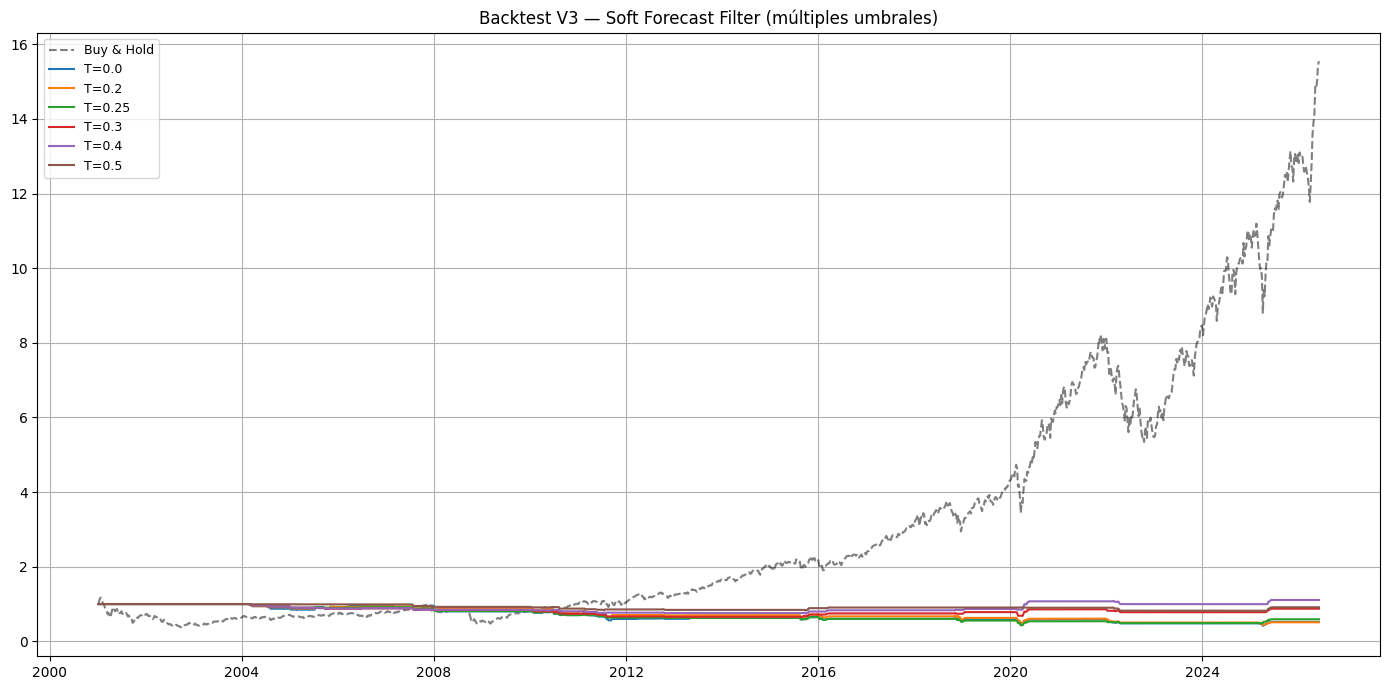

In [33]:
# =========================================================
# BLOQUE 30 — BACKTEST V3: SOFT FILTER THRESHOLD SWEEP
# =========================================================

df = final_weekly_structure.copy()
df["asset_return"] = df["Close"].pct_change()

trend_on = (df["feat_sma"] == 1) & (df["feat_mom"] == 1)
thresholds = [0.0, 0.20, 0.25, 0.30, 0.40, 0.50]

fig, ax = plt.subplots(figsize=(14, 7))
bh = (1 + df["asset_return"].fillna(0)).cumprod()
ax.plot(df.index, bh, label="Buy & Hold", linestyle="--", alpha=0.5, color="black")

print("\n📊 BACKTEST V3 — Soft Filter (threshold sweep)")
print(f"{'Threshold':>12} {'CAGR':>8} {'MaxDD':>8} {'Sharpe':>8} {'Exposure':>10}")
print("─" * 50)

for t in thresholds:
    pos  = np.where(trend_on & (df["pred_prob_bull"] > t), 1, 0)
    ret  = pd.Series(pos, index=df.index).shift(1).fillna(0) * df["asset_return"]
    eq   = (1 + ret.fillna(0)).cumprod()
    exp  = pd.Series(pos, index=df.index).mean()
    label = f"T={t}"
    ax.plot(df.index, eq, label=label)
    print(f"{t:>12.2f} {cagr(eq):>8.2%} {max_dd(eq):>8.2%} {sharpe(ret):>8.2f} {exp:>10.2%}")

ax.set_title("Backtest V3 — Soft Forecast Filter (múltiples umbrales)")
ax.legend(fontsize=9); ax.grid(True)
plt.tight_layout(); plt.show()


### BLOQUE 31 — Backtest V4: Trade Strength Score continuo

Usamos el score completo normalizado como tamaño de posición.
Más parecido a cómo operan fondos cuantitativos reales: la posición
varía suavemente entre 0% y 100% según la convicción.

```python
position = clip(trade_strength / max(trade_strength), 0, 1)
```



📊 BACKTEST V4 — Trade Strength Score
                            Buy&Hold   V0 (bin)   V4 (score)
───────────────────────────────────────────────────────
CAGR                          11.35%     10.65%       -2.24%
Max Drawdown                 -69.31%    -27.25%      -54.09%
Sharpe                          0.59       0.74        -0.23
Avg Position                    100%     71.36%       50.35%


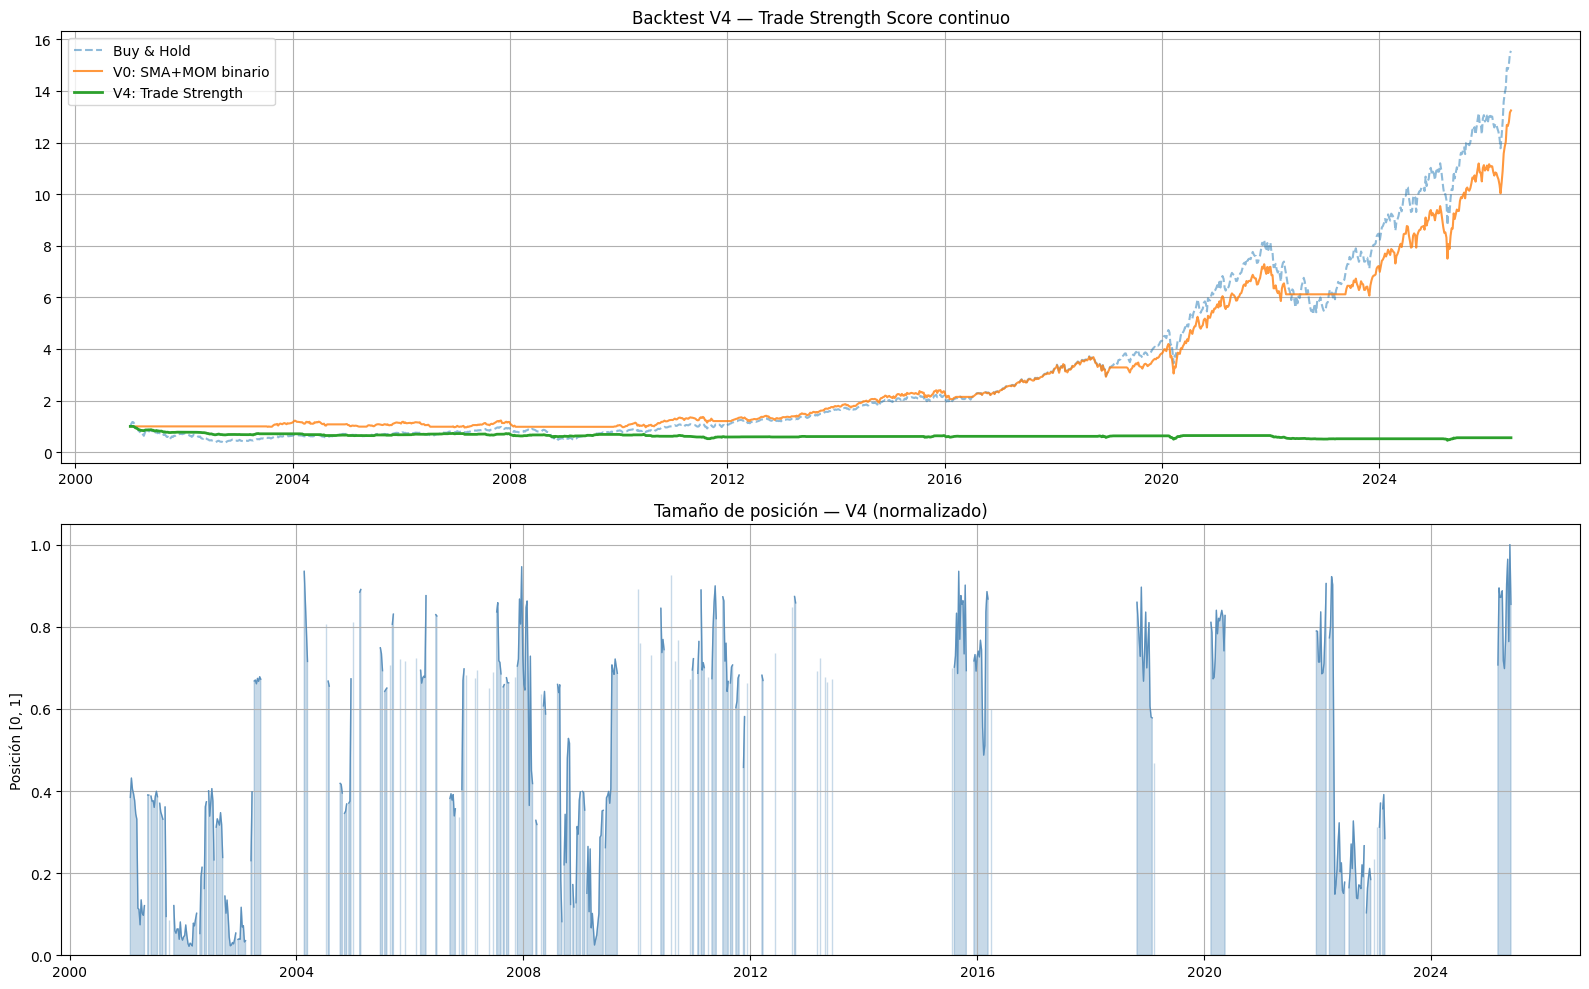

In [34]:
# =========================================================
# BLOQUE 31 — BACKTEST V4: TRADE STRENGTH SCORE (continuo)
# =========================================================

df = final_weekly_structure.copy()
df["asset_return"] = df["Close"].pct_change()

ts = (
      2 * df["feat_sma"]
    + 2 * df["feat_mom"]
    + 1 * df["feat_bb"]
    + 3 * df["pred_prob_bull"]
)

score_max = ts.max()
df["position"] = (ts / score_max).clip(0, 1)

df["strategy_return"] = df["position"].shift(1).fillna(0) * df["asset_return"]
df["strategy"] = (1 + df["strategy_return"].fillna(0)).cumprod()
df["buy_hold"]  = (1 + df["asset_return"].fillna(0)).cumprod()

trend_on = (df["feat_sma"] == 1) & (df["feat_mom"] == 1)
df["v0_pos"] = np.where(trend_on, 1, 0)
df["v0_ret"] = df["v0_pos"].shift(1).fillna(0) * df["asset_return"]
df["v0_eq"]  = (1 + df["v0_ret"].fillna(0)).cumprod()

print("\n📊 BACKTEST V4 — Trade Strength Score")
print(f"{'':25s} {'Buy&Hold':>10} {'V0 (bin)':>10} {'V4 (score)':>12}")
print("─" * 55)
print(f"{'CAGR':25s} {cagr(df['buy_hold']):>10.2%} {cagr(df['v0_eq']):>10.2%} {cagr(df['strategy']):>12.2%}")
print(f"{'Max Drawdown':25s} {max_dd(df['buy_hold']):>10.2%} {max_dd(df['v0_eq']):>10.2%} {max_dd(df['strategy']):>12.2%}")
print(f"{'Sharpe':25s} {sharpe(df['asset_return']):>10.2f} {sharpe(df['v0_ret']):>10.2f} {sharpe(df['strategy_return']):>12.2f}")
print(f"{'Avg Position':25s} {'100%':>10} {df['v0_pos'].mean():>10.2%} {df['position'].mean():>12.2%}")

fig, axes = plt.subplots(2, 1, figsize=(16, 10))
axes[0].plot(df.index, df["buy_hold"], label="Buy & Hold", alpha=0.5, linestyle="--")
axes[0].plot(df.index, df["v0_eq"],  label="V0: SMA+MOM binario", alpha=0.8)
axes[0].plot(df.index, df["strategy"], label="V4: Trade Strength", linewidth=2)
axes[0].set_title("Backtest V4 — Trade Strength Score continuo")
axes[0].legend(); axes[0].grid(True)

axes[1].plot(df.index, df["position"], linewidth=1, alpha=0.8, color="steelblue")
axes[1].fill_between(df.index, df["position"], alpha=0.3, color="steelblue")
axes[1].set_title("Tamaño de posición — V4 (normalizado)")
axes[1].set_ylabel("Posición [0, 1]")
axes[1].set_ylim(0, 1.05); axes[1].grid(True)

plt.tight_layout(); plt.show()


### BLOQUE 32 — Resumen comparativo de todos los backtests



📊 RESUMEN COMPARATIVO — Todos los Backtests


,CAGR,MaxDD,Sharpe,Exposure
version,,,,
V0 SMA+MOM,10.65%,-27.25%,0.74,71.4%
V1 +Forecast>0.5,-0.35%,-17.87%,-0.12,2.5%
V2 SMA+MOM×prob,-0.58%,-22.72%,-0.17,10.3%
V3 +Forecast>0.25,-2.04%,-57.11%,-0.25,7.2%
V4 TradeStrength,-2.24%,-54.09%,-0.23,50.3%


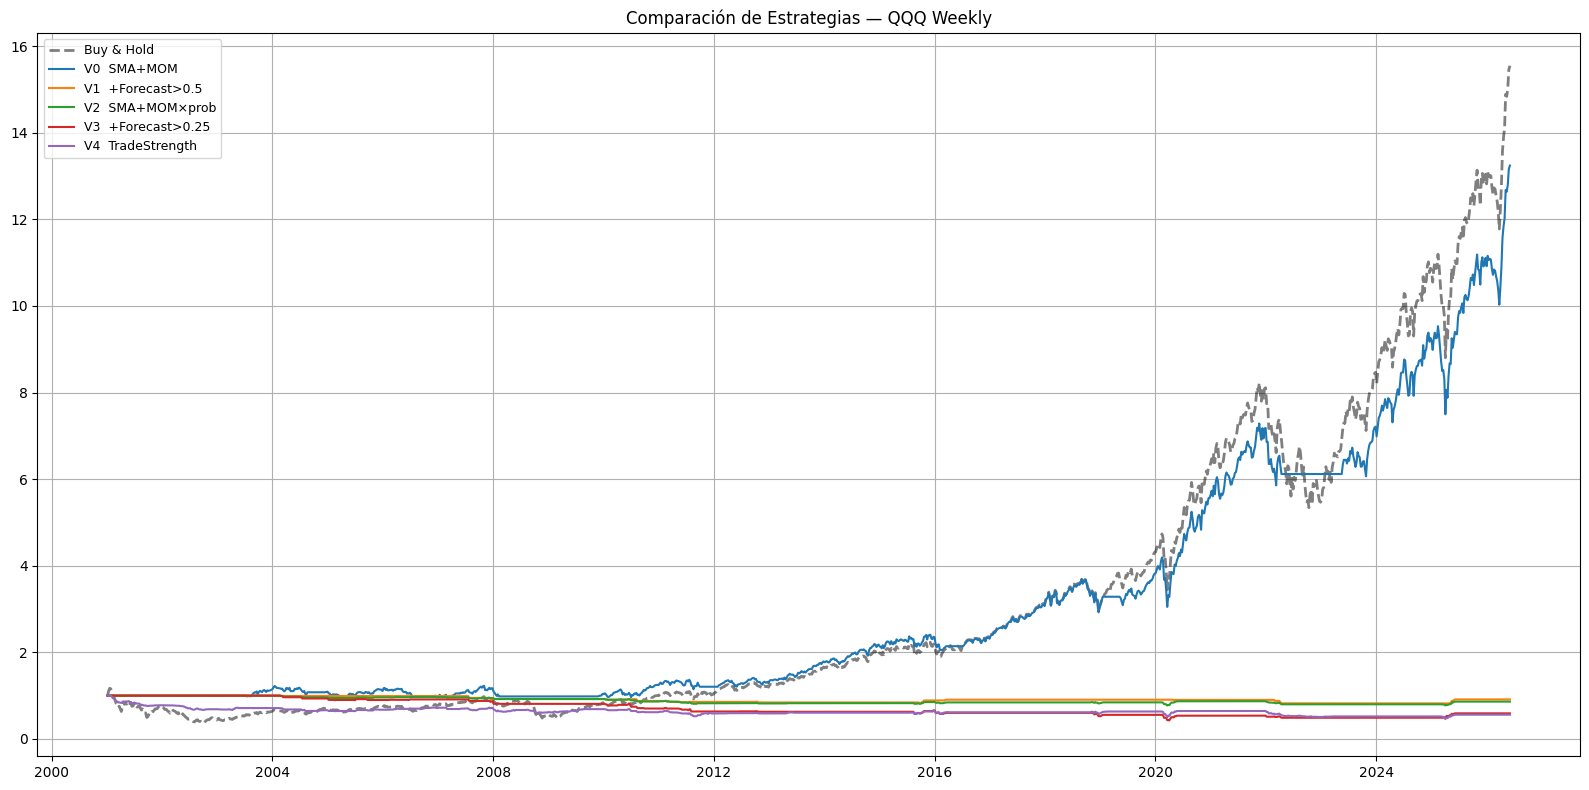

In [35]:
# =========================================================
# BLOQUE 32 — RESUMEN COMPARATIVO (V0 → V4)
# =========================================================

df = final_weekly_structure.copy()
df["asset_return"] = df["Close"].pct_change()

trend_on = (df["feat_sma"] == 1) & (df["feat_mom"] == 1)

ts = (2*df["feat_sma"] + 2*df["feat_mom"] + df["feat_bb"] + 3*df["pred_prob_bull"])

pos_v0 = np.where(trend_on, 1, 0)
pos_v1 = np.where(trend_on & (df["pred_prob_bull"] > 0.50), 1, 0)
pos_v2 = np.where(trend_on, df["pred_prob_bull"], 0)
pos_v3 = np.where(trend_on & (df["pred_prob_bull"] > 0.25), 1, 0)
pos_v4 = (ts / ts.max()).clip(0, 1).values

def run_backtest(pos_arr, label, df_):
    pos = pd.Series(pos_arr, index=df_.index)
    ret = pos.shift(1).fillna(0) * df_["asset_return"]
    eq  = (1 + ret.fillna(0)).cumprod()
    return {
        "version":  label,
        "CAGR":     cagr(eq),
        "MaxDD":    max_dd(eq),
        "Sharpe":   sharpe(ret),
        "Exposure": pos.mean(),
    }, eq

rows, equities = [], []
for pos, label in [
    (pos_v0, "V0  SMA+MOM"),
    (pos_v1, "V1  +Forecast>0.5"),
    (pos_v2, "V2  SMA+MOM×prob"),
    (pos_v3, "V3  +Forecast>0.25"),
    (pos_v4, "V4  TradeStrength"),
]:
    r, eq = run_backtest(pos, label, df)
    rows.append(r)
    equities.append((label, eq))

comp = pd.DataFrame(rows).set_index("version")
for col in ["CAGR", "MaxDD"]:
    comp[col] = comp[col].map("{:.2%}".format)
comp["Sharpe"]   = comp["Sharpe"].map("{:.2f}".format)
comp["Exposure"] = comp["Exposure"].map("{:.1%}".format)

print("\n📊 RESUMEN COMPARATIVO — Todos los Backtests")
display(comp)

bh = (1 + df["asset_return"].fillna(0)).cumprod()

plt.figure(figsize=(16, 8))
plt.plot(df.index, bh, label="Buy & Hold", linestyle="--", alpha=0.5, color="black", linewidth=2)
for label, eq in equities:
    plt.plot(df.index, eq, label=label)
plt.title("Comparación de Estrategias — QQQ Weekly")
plt.legend(fontsize=9); plt.grid(True); plt.tight_layout(); plt.show()


### BLOQUE 33 — Backtest de signature: trades no solapados

Tomamos la mejor signature identificada y simulamos un backtest realista:
- Solo entramos cuando aparece la signature en la semana t.
- Holding period fijo de 12 semanas.
- No solapamos trades: si ya estamos en posición, no abrimos nueva.


Signature objetivo : 001000
Señales totales    : 31
Holding period     : 12 semanas
Trades ejecutados  : 6

📊 TRADE STATS


,trades,avg_return,median_return,hit_rate,best_trade,worst_trade
0,6,0.1091,0.1186,1.0,0.1512,0.0412


,entry_date,exit_date,return
0,2003-05-23,2003-08-15,0.1093
1,2005-04-29,2005-07-22,0.1280
2,2008-02-22,2008-05-16,0.1458
3,2009-09-04,2009-11-27,0.0791
4,2016-02-19,2016-05-13,0.0412
5,2023-04-14,2023-07-07,0.1512



Strategy total return : 85.43%
Buy & Hold (período)  : 1420.20%
Excess return         : -1334.78%


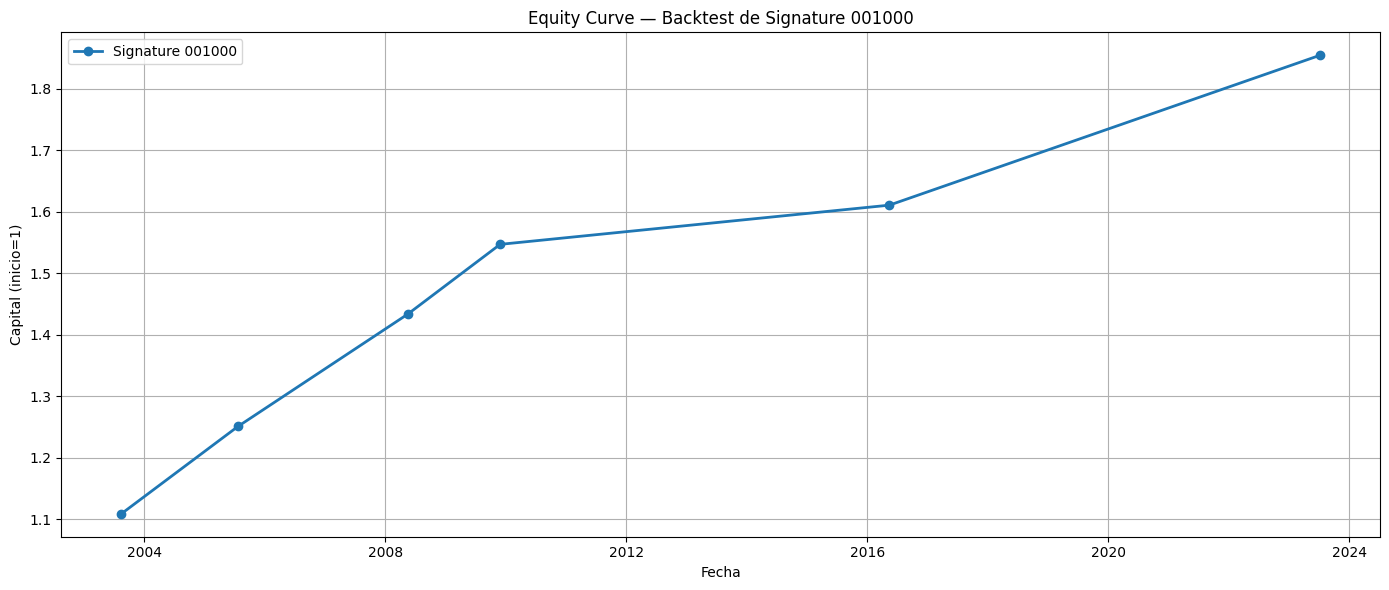

In [36]:
# =========================================================
# BLOQUE 33 — BACKTEST DE SIGNATURE (non-overlapping trades)
# =========================================================

BEST_SIGNATURE  = robust_sigs.iloc[0]["signature"]
HOLDING_PERIOD  = 12

df = final_weekly_structure.copy()
SIGNAL_COLS = ["feat_rsi", "feat_bb", "feat_sma", "feat_mom", "feat_bull", "feat_conf"]
df["signature"] = df[SIGNAL_COLS].astype(int).astype(str).agg("".join, axis=1)
df["signal"]    = (df["signature"] == BEST_SIGNATURE).astype(int)

print(f"Signature objetivo : {BEST_SIGNATURE}")
print(f"Señales totales    : {df['signal'].sum()}")
print(f"Holding period     : {HOLDING_PERIOD} semanas")

# ─── Non-overlapping entries ─────────────────────────────
entries   = []
last_exit = -999
for i in range(len(df)):
    if i <= last_exit:
        continue
    if df["signal"].iloc[i] == 1:
        entries.append(i)
        last_exit = i + HOLDING_PERIOD

print(f"Trades ejecutados  : {len(entries)}")

# ─── Trade log ───────────────────────────────────────────
trades = []
for entry_idx in entries:
    exit_idx = entry_idx + HOLDING_PERIOD
    if exit_idx >= len(df):
        continue
    entry_price = df["Close"].iloc[entry_idx]
    exit_price  = df["Close"].iloc[exit_idx]
    trades.append({
        "entry_date":  df.index[entry_idx],
        "exit_date":   df.index[exit_idx],
        "return":      exit_price / entry_price - 1,
    })

trades = pd.DataFrame(trades)

# ─── Estadísticas ────────────────────────────────────────
stats = pd.DataFrame({
    "trades":         [len(trades)],
    "avg_return":     [trades["return"].mean()],
    "median_return":  [trades["return"].median()],
    "hit_rate":       [(trades["return"] > 0).mean()],
    "best_trade":     [trades["return"].max()],
    "worst_trade":    [trades["return"].min()],
})
print("\n📊 TRADE STATS")
display(stats.round(4))
display(trades.head(10).round(4))

# ─── Equity curve ────────────────────────────────────────
capital = 1.0
equity, dates = [], []
for _, trade in trades.iterrows():
    capital *= (1 + trade["return"])
    equity.append(capital)
    dates.append(trade["exit_date"])

equity_curve = pd.Series(equity, index=dates, name="equity")

# Buy & Hold en el mismo período
bh_start = trades["entry_date"].min()
bh_end   = trades["exit_date"].max()
bh_slice = df.loc[bh_start:bh_end, "Close"]
bh_return = bh_slice.iloc[-1] / bh_slice.iloc[0] - 1

print(f"\nStrategy total return : {capital - 1:.2%}")
print(f"Buy & Hold (período)  : {bh_return:.2%}")
print(f"Excess return         : {(capital - 1) - bh_return:.2%}")

plt.figure(figsize=(14, 6))
plt.plot(equity_curve.index, equity_curve.values, marker="o", linewidth=2, label=f"Signature {BEST_SIGNATURE}")
plt.title(f"Equity Curve — Backtest de Signature {BEST_SIGNATURE}")
plt.xlabel("Fecha"); plt.ylabel("Capital (inicio=1)")
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()


---
## 📋 Parte 10 — Conclusiones
### BLOQUE 34 — Resumen de hallazgos


In [1]:
# =========================================================
# BLOQUE 34 — RESUMEN EJECUTIVO DE HALLAZGOS
# =========================================================

print("""
==============================================================
              CONCLUSIONES FINALES – QQQ RESEARCH
==============================================================

1. HIPÓTESIS ORIGINAL

• Objetivo:
  Determinar si los regímenes de mercado, su forecast y sus
  transiciones contenían suficiente información para generar
  una ventaja operativa explotable en trading.

• Resultado:
  La hipótesis original fue rechazada como sistema operativo
  principal.

• Lo aprendido:
  Los regímenes sí contienen información económica real y el
  forecast sí captura estructura estadística, pero ninguno de
  los dos por sí solo demostró ser una fuente robusta de alpha
  aplicable de forma directa.

• Interpretación final:
  El proyecto no fracasó; evolucionó. La tesis inicial sirvió
  para descubrir que el régimen es útil como contexto, pero no
  como motor principal de una estrategia rentable.


2. CLUSTERING Y META-ESTADOS

• UMAP + HDBSCAN sí logró identificar estados de mercado con
  sentido económico, pero esos estados no deben interpretarse
  literalmente como “mercado alcista” o “mercado bajista” en
  sentido tradicional.

• Los meta-estados capturan estructuras de comportamiento y
  transiciones, no necesariamente una clasificación simple del
  ciclo bursátil.

• Hallazgo importante:
  - Neutral resultó ser el estado más persistente.
  - Bull y Stress aparecen con duraciones cortas y tienden a
    funcionar más como episodios transitorios que como estados
    permanentes.

• Conclusión:
  El clustering sí describe contexto estructural, pero no
  entrega una regla de trading autónoma.


3. FORECAST SUPERVISADO (XGBOOST)

• El modelo supervisado mostró señal estadística real.

• La calibración de `pred_prob_bull` fue razonable y la curva
  de calibración mostró que las probabilidades sí reflejan, en
  promedio, la frecuencia observada del estado Bull.

• Sin embargo:
  Forecast ≠ Alpha

• Lo más importante:
  La probabilidad estimada aporta información contextual, pero
  no implica necesariamente una mejora operativa cuando se usa
  como filtro duro o como gatillo de entrada.

• Conclusión:
  El forecast funciona mejor como descriptor del estado del
  mercado que como señal de timing directa.


4. ANALISIS DE THRESHOLDS

• Se probaron múltiples umbrales sobre `pred_prob_bull`.

• La evidencia fue consistente:
  - al subir el threshold baja la cobertura;
  - sube la pureza del forecast;
  - pero no mejora de forma robusta el retorno operativo.

• Hallazgo clave:
  Los umbrales altos reducen demasiado la exposición y
  destruyen el CAGR o la relación retorno/riesgo.

• Conclusión:
  El forecast no es una buena señal binaria de entrada/salida.
  Puede tener valor como información continua o como parte de un
  ranking, pero no como filtro duro principal.


5. TRANSICIONES DE REGIMEN

• Se estudió especialmente la transición Stress → Bull.

• El forecast tiende a subir antes del cambio formal de régimen
  y, en varios casos, el mercado ya empieza a mejorar antes de
  que el cluster cambie de estado.

• Hallazgo importante:
  El modelo parece confirmar cambios que ya están en desarrollo
  más que anticiparlos con ventaja suficiente para trading.

• Conclusión:
  El régimen captura la transición una vez que ya está bastante
  avanzada. Eso lo hace útil como contexto, pero insuficiente
  como gatillo operativo por sí solo.


6. ANALISIS DE FEATURES

• Las variables más útiles no fueron las más “sofisticadas”.

• A lo largo de todo el proyecto, las señales más consistentes
  fueron:
    - SMA
    - MOM
    - price_vs_sma_52
    - trend_13_52
    - drawdown
    - atr_pct

• Lectura general:
  El motor de información está en tendencia, momentum y
  persistencia estructural, no en la predicción del régimen
  como variable aislada.

• Conclusión:
  La persistencia resultó más importante que el cambio de
  régimen. La mayor parte del edge descriptivo proviene de
  lectura de tendencia, no de clasificación de estados.


7. COMBINACIONES Y SIGNATURES

• Las signatures aportaron más información que los regímenes
  por sí solos.

• Se identificaron firmas con retornos futuros atractivos y
  con comportamiento temporal razonablemente estable.

• La firma más robusta a nivel conceptual fue aquella que
  concentran tendencia y momentum, especialmente:

      001100

  equivalente a:

      SMA = 1
      MOM = 1

• También aparecieron firmas de muy alta calidad por trade, como
  001000, pero con cobertura mucho menor.

• Conclusión:
  Las mejores firmas no son necesariamente las más “ricas” en
  señales, sino las más coherentes con tendencia + momentum.


8. LECCION PRINCIPAL

• Las mejores signatures no identifican cambios de régimen.
  Identifican persistencia.

• En la mayoría de los casos exitosos:
  - la tendencia ya era positiva,
  - el momentum ya era positivo,
  - el mercado ya estaba mostrando continuidad alcista.

• Lo que funciona no es “adivinar el giro”, sino reconocer
  cuándo el entorno sigue siendo favorable.

• Conclusión:
  El sistema funciona mejor describiendo continuidad que
  anticipando rupturas.


9. VALIDACION OPERACIONAL

• Se probó convertir firmas y filtros en estrategias reales.

• Resultado general:
  - Los filtros duros sobre `pred_prob_bull` destruyen valor.
  - Los intentos de position sizing usando la probabilidad del
    forecast también empeoran el rendimiento.
  - El “trade strength score” no mostró monotonicidad robusta
    ni una frontera operativa estable.

• Hallazgo clave:
  El mejor baseline operativo fue el enfoque binario SMA + MOM
  (V0), que mantuvo el mejor equilibrio entre retorno, Sharpe,
  drawdown y exposición de todos los experimentos comparados.

• Conclusión:
  Una buena señal descriptiva no garantiza una buena estrategia.
  El mejor resultado operativo provino de la estructura más
  simple y estable, no del agregado más complejo.


10. APRENDIZAJES DEL PROYECTO

• Forecast ≠ Alpha

• Buena calibración ≠ Rentabilidad

• Contexto ≠ Edge

• Clasificación ≠ Timing

• Señal ≠ Estrategia

• Persistencia > Cambio de régimen

• Más complejidad no significa más valor.

• El forecast y los meta-estados son útiles para comprender el
  mercado, pero el edge operativo más robusto surgió de SMA +
  Momentum y de firmas simples, coherentes y persistentes.

• En varios casos, añadir `feat_bull` o `feat_conf` degradó el
  resultado en vez de mejorarlo.


11. ESTADO DEL PROYECTO

• QQQ Research – Parte 1

• Estado:
      COMPLETADO

• Resultado:
      La hipótesis original basada en régimen/forecast fue
      rechazada como estrategia principal, pero la investigación
      permitió identificar un baseline operativo mucho más
      robusto y estable: SMA + MOM.

• Aprendizaje validado:
      La mejor señal no fue la más compleja, sino la más
      consistente.

• Base metodológica construida:
      - clustering
      - forecast
      - calibración
      - thresholds
      - transitions
      - signatures
      - backtests
      - comparación con mercado
      - validación temporal

==============================================================
""")



              CONCLUSIONES FINALES – QQQ RESEARCH

1. HIPÓTESIS ORIGINAL

• Objetivo:
  Determinar si los regímenes de mercado, su forecast y sus
  transiciones contenían suficiente información para generar
  una ventaja operativa explotable en trading.

• Resultado:
  La hipótesis original fue rechazada como sistema operativo
  principal.

• Lo aprendido:
  Los regímenes sí contienen información económica real y el
  forecast sí captura estructura estadística, pero ninguno de
  los dos por sí solo demostró ser una fuente robusta de alpha
  aplicable de forma directa.

• Interpretación final:
  El proyecto no fracasó; evolucionó. La tesis inicial sirvió
  para descubrir que el régimen es útil como contexto, pero no
  como motor principal de una estrategia rentable.


2. CLUSTERING Y META-ESTADOS

• UMAP + HDBSCAN sí logró identificar estados de mercado con
  sentido económico, pero esos estados no deben interpretarse
  literalmente como “mercado alcista” o “mercado bajista” en
  senti